# 1. Answer the questions from the Preamble and Introduction


## For which of the models already studied is the curse of dimensionality relevant and explain why.


- Проклятие размерности (curse of dimensionality) - явление, при котором с ростом числа измерений (размерности) объём пространства растёт настолько быстро, что доступные данные становятся разреженными и нерепрезентативными.

Возникающие проблемы:
1) Разреженность данных: в многомерном пространстве все объекты (точки данных) становятся чрезвычайно далеко друг от друга. Объём пространства растёт экспоненциально с ростом размерности;

2) Бесполезность понятия "близости": в очень высоких размерностях расстояние от точки до её ближайшего соседа стремится стать почти таким же, как и до самой дальней точки (https://habr.com/ru/companies/wunderfund/articles/748044/);

3) Переобучение: при большом количестве признаков модель может запомнить шум. Нужно гораздо больше данных для надёжного обучения;

4) Рост вычислительной сложности: объём вычислений и требуемая память растут экспоненциально;

5) Визуализация и интерпретируемость.

Соответственно, вследствие п.1, 2 больше всего ухудшается эффективность методов, основанных на расстояниях между точками (kNN, алгоритмы кластеризации), а также методов, предусматривающих перебор данных (GridSearch), так как для того, чтобы уложиться в одни и те же линейные интервалы, надо будет перебрать больше значений.
Линейные модели также страдают, но в меньшей степени, через риск переобучения при малом количестве наблюдений (меньше, чем признаков или сопоставимо) и сложности с оптимизацией. Плюс у линейных моделей есть способы борьбы с проклятием размерности - регуляризация.

## What is the difference between PCA and SVD?

**PCA (Principal Component Analysis)**
PCA — это метод уменьшения размерности, который преобразует набор, возможно, коррелированных переменных в набор некоррелированных переменных, называемых главными компонентами. Основная идея заключается в нахождении направлений (главных компонент), вдоль которых данные имеют наибольшую дисперсию.

**Основные части алгоритма:**

- **Стандартизация данных**: Если признаки имеют разные масштабы, данные центрируются (вычитается среднее) и масштабируются (делятся на стандартное отклонение), чтобы каждый признак вносил одинаковый вклад.

Формула для Z-стандартизации отдельного значения $x$:

$$ z = \frac{x - \mu}{\sigma} $$

Где:

$x$ — отдельное значение признака.
$\mu$ — среднее значение признака.
$\sigma$ — стандартное отклонение признака.

- **Вычисление ковариационной матрицы**: Определяется ковариационная матрица для стандартизированных данных. Эта матрица показывает, как признаки изменяются вместе.

Для набора данных с $n$ наблюдениями и $p$ признаками (столбцами), ковариационная матрица $C$ размером $p \times p$ вычисляется следующим образом:

$$ C = \frac{1}{n-1} (X - \bar{X})^T (X - \bar{X}) $$

Где:

$X$ — матрица данных размером $n \times p$, где каждый столбец представляет признак, а каждая строка — наблюдение.

$\bar{X}$ — матрица средних значений, где каждая строка содержит вектор средних значений по всем признакам (то есть, каждый столбец $X$ вычитается из его среднего).

$n$ — количество наблюдений.
$(n-1)$ используется для несмещенной оценки ковариации (если это выборка). Для генеральной совокупности используется $n$.


Элемент $C_{ij}$ ковариационной матрицы (ковариация между признаками $i$ и $j$) вычисляется как:

$$ \text{cov}(X_i, X_j) = \frac{\sum_{k=1}^{n} (x_{ki} - \mu_i)(x_{kj} - \mu_j)}{n-1} $$

Где:

$X_i$ и $X_j$ — $i$-й и $j$-й признаки (столбцы) из матрицы данных $X$.
$x_{ki}$ — $k$-е наблюдение $i$-го признака.
$\mu_i$ и $\mu_j$ — средние значения $i$-го и $j$-го признаков соответственно.
Когда $i = j$, элемент $C_{ii}$ представляет  собой дисперсию $i$-го признака:

$$ \text{var}(X_i) = \text{cov}(X_i, X_i) = \frac{\sum_{k=1}^{n} (x_{ki} - \mu_i)^2}{n-1} $$



- **Нахождение собственных векторов и собственных значений**: Вычисляются собственные векторы и соответствующие им собственные значения ковариационной матрицы.

**Формула связи собственных векторов и собственных значений**

**Собственный вектор** ($v$) матрицы $A$ — это ненулевой вектор, который при умножении на матрицу $A$ изменяется только в масштабе (растягивается или сжимается), но не меняет своего направления. Коэффициент масштабирования называется **собственным значением** ($\lambda$).

Формально это выражается следующим уравнением:

$$ Av = \lambda v $$

Где:

$A$ — квадратная матрица (размером $n \times n$$n \times n$).
$v$ — собственный вектор матрицы $A$$A$ (ненулевой вектор).
$\lambda$ — соответствующее собственное значение (скаляр).
Чтобы найти собственные значения, уравнение обычно переписывается так:

$$ Av - \lambda v = 0 $$ $$ (A - \lambda I) v = 0 $$

Где $I$ — единичная матрица того же размера, что и $A$. Для того чтобы это уравнение имело нетривиальные решения (то есть $v \neq 0$), определитель матрицы $(A - \lambda I)$должен быть равен нулю:

$$ \text{det}(A - \lambda I) = 0 $$

Решение этого характеристического уравнения позволяет найти собственные значения $\lambda$. После нахождения $\lambda$, их можно подставить обратно в уравнение $(A - \lambda I) v = 0$ для нахождения соответствующих собственных векторов $v$.

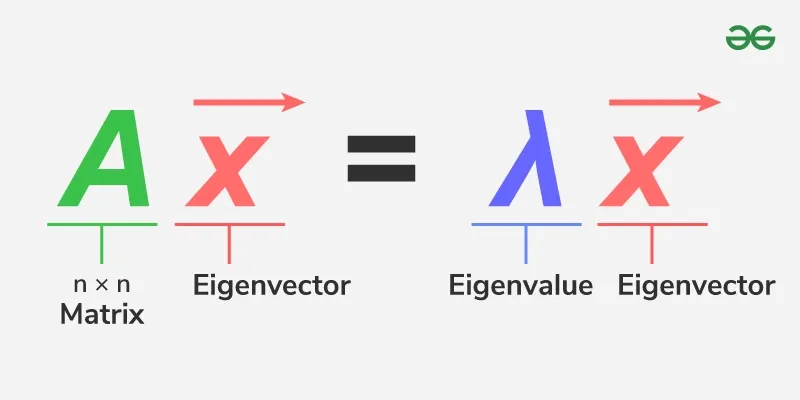

- Собственные векторы определяют направления главных компонент (оси нового пространства).
- Собственные значения указывают на величину дисперсии вдоль соответствующего собственного вектора. Чем больше собственное значение, тем больше дисперсии объясняет эта компонента.

- **Выбор главных компонент**: Собственные векторы сортируются по убыванию их собственных значений. Выбирается k собственных векторов с наибольшими собственными значениями, где k — желаемая новая размерность.

- **Проекция данных**: Исходные данные проецируются на выбранные k собственных векторов, формируя новое, уменьшенное по размерности представление данных.

- Однако в большинстве современных реализаций PCA работает через **сингулярное разложение центрированной матрицы данных** (где из каждого столбца признака вычтено его среднее), тк это численно более устойчиво и эффективно (например, работает для случая, когда число признаков больше числа наблюдений - классический алгоритм в таком случае столкнется с проблемами в вычислениях из-за вырожденности ковариационной матрицы). Описанный выше классический алгоритм - это по сути спектральное разложение симметричной ковариационной матрицы.

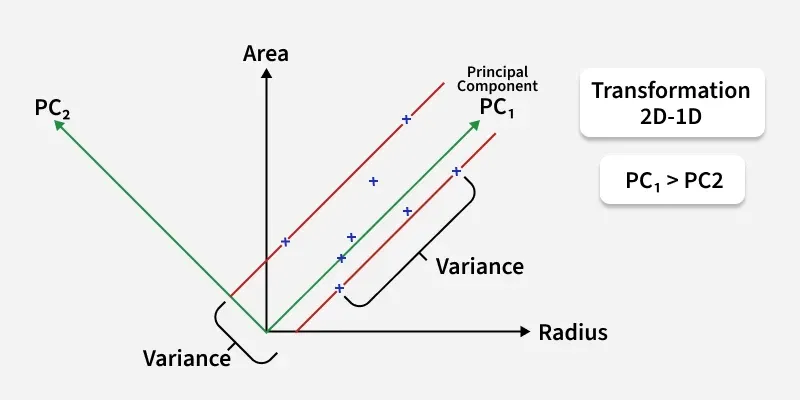

**SVD (Singular Value Decomposition)**
- SVD — это метод разложения матрицы, который представляет любую матрицу A как произведение трех других матриц:

$A = U \Sigma V^T$

Это мощный инструмент с широким спектром применений, включая уменьшение размерности.

**Основные части алгоритма:**

- **Разложение матрицы**: Любая действительная матрица $A$ размера $m \times n$ может быть разложена следующим образом: $$ A = U \Sigma V^T $$
Где:

$U$ — ортогональная матрица размера $m \times m$, столбцы которой называются левыми сингулярными векторами.

$\Sigma$ (Сигма) — прямоугольная диагональная матрица размера $m \times n$, содержащая неотрицательные сингулярные числа на главной диагонали, отсортированные в убывающем порядке ($\sigma_1 \ge \sigma_2 \ge \dots \ge 0$). Все остальные элементы равны нулю.

$V^T$ — транспонированная ортогональная матрица размера $n \times n$, строки которой называются правыми сингулярными векторами.

- **Вычисление сингулярных чисел и векторов**:

Квадраты сингулярных чисел ($\sigma_i^2$) являются собственными значениями матриц $A^T A$ и $A A^T$.

Правые сингулярные векторы (столбцы $V$) являются собственными векторами $A^T A$.

Левые сингулярные векторы (столбцы $U$) являются собственными векторами $A A^T$.


- **Уменьшение размерности**:

Для уменьшения размерности можно аппроксимировать матрицу $A$, используя только $k$ наибольших сингулярных чисел и соответствующие им сингулярные векторы. Для этого используются первые $k$ столбцов $U$, первые $k$ строк $V^T$ и первые $k$ сингулярных значений из $\Sigma$.

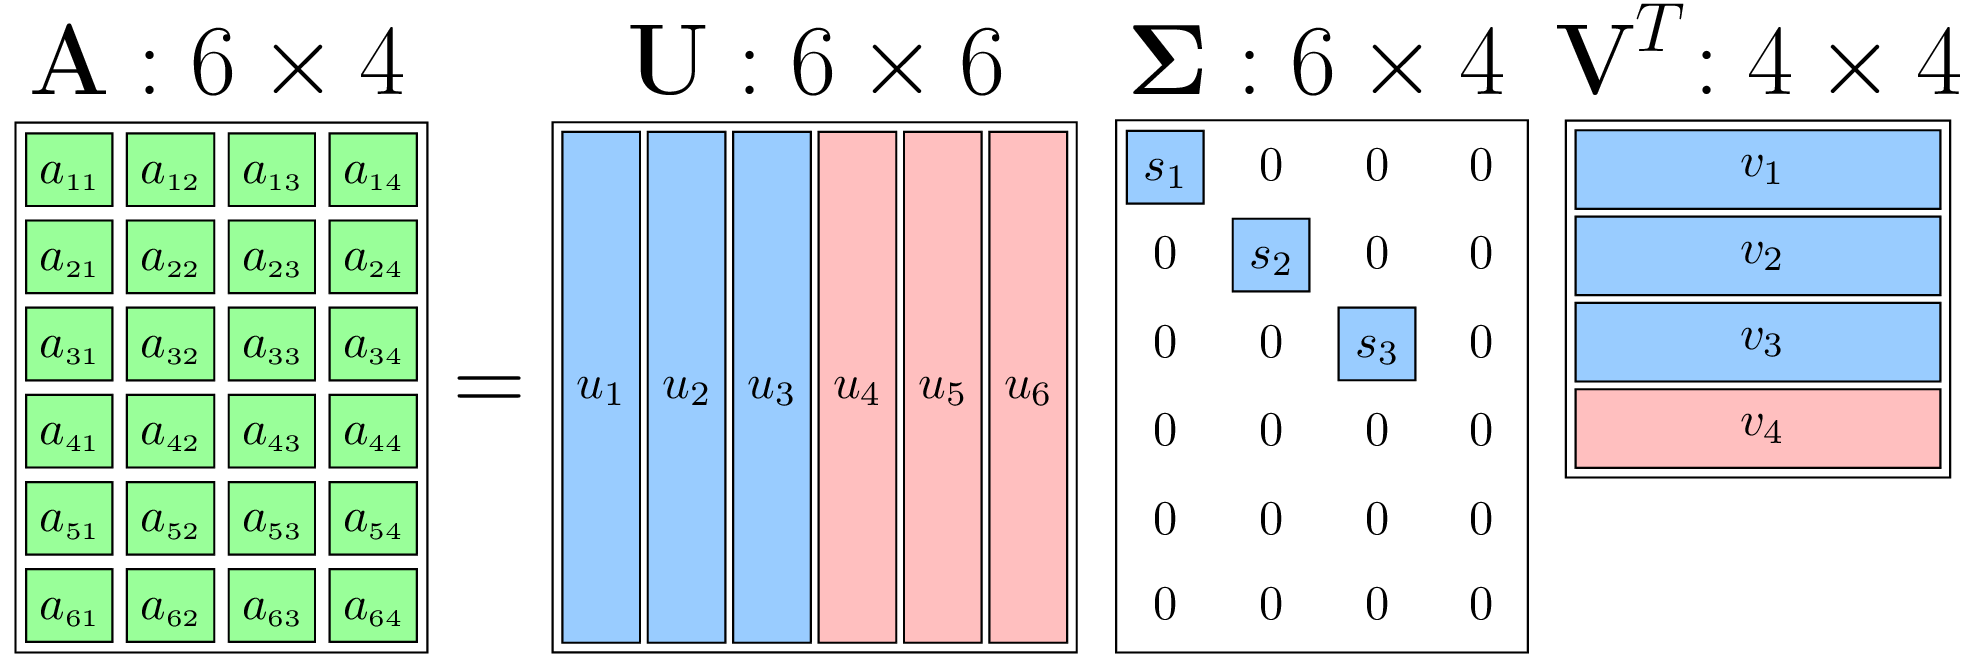

**Различия между PCA и SVD**

Хотя PCA и SVD тесно связаны и часто используются для одних и тех же целей (уменьшение размерности), между ними есть ключевые различия:

- **Природа методов**: SVD является общим методом разложения матрицы, применимым к любой матрице (это как аналог разложения любой функции в ряд Фурье, только в мире матриц). PCA — это статистический метод анализа данных, который фокусируется на поиске направлений максимальной дисперсии.

- **Взаимосвязь**: PCA может быть реализован с использованием SVD. Если выполнять SVD на центрированной матрице данных (где из каждого столбца вычтено его среднее), то правые сингулярные векторы ($V$) будут соответствовать главным компонентам PCA, а сингулярные числа ($\Sigma$) будут связаны с дисперсиями вдоль этих компонент.

- **Цель**: Основная цель PCA — уменьшение размерности и визуализация данных с сохранением наибольшей дисперсии. SVD имеет более широкие применения, включая псевдообращение матриц, анализ скрытых семантических отношений (LSA), сжатие изображений и разработку рекомендательных систем.

- **Требования к данным**: PCA обычно применяется к данным с числовыми признаками и часто требует предварительной стандартизации. SVD может быть применен к любой матрице, включая разреженные или неквадратные матрицы, без строгих предварительных требований (хотя центрирование данных важно при использовании SVD для выполнения PCA).

## What is the difference between NMF and SVD?

Инфо про SVD смотри выше.

**NMF (Non-negative Matrix Factorization)**

NMF — это метод уменьшения размерности, в основе которого лежит возможность приближения любой матрицы двумя другими матрицами с неотрицательными компонентами. Он особенно полезен, когда данные (например, изображения, текстовые документы) по своей природе являются неотрицательными, и требуется найти неотрицательные скрытые факторы.

Основная идея NMF заключается в разложении исходной неотрицательной матрицы $V$на две другие неотрицательные матрицы, $W$ и $H$, такие что:

$$ V \approx WH $$

Где:

$V$ — исходная матрица данных (размером $m \times n$, все элементы $V_{ij} \ge 0$).

$W$ — матрица базисных векторов или компонентов (размером $m \times r$, все элементы $W_{ij} \ge 0$).

$H$ — матрица активаций или весов (размером $r \times n$, все элементы $H_{ij} \ge 0$).

$r$ — это выбранная меньшая размерность, представляющая количество скрытых факторов или компонентов.

В отличие от SVD, где компоненты могут быть как положительными, так и отрицательными, NMF требует, чтобы все элементы матриц $W$ и $H$ были неотрицательными. Это часто приводит к более интерпретируемым результатам, особенно в областях, где данные представляют собой агрегации (например, количество слов в документе или интенсивность пикселей в изображении).

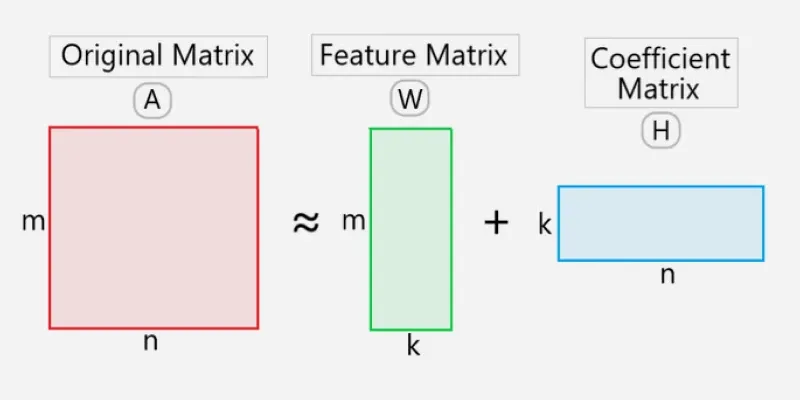

**Различия между SVD и NMF**
Ключевые различия между SVD и NMF:

- Ограничение неотрицательности:

SVD: Не накладывает ограничений на знак элементов в матрицах $U$, $\Sigma$ и $V^T$. Сингулярные векторы могут содержать как положительные, так и отрицательные значения.

NMF: Требует, чтобы все элементы в результирующих матрицах $W$ и $H$ были неотрицательными.

- Интерпретируемость:

SVD: Компоненты, извлекаемые SVD, могут быть менее интуитивно интерпретируемыми, поскольку они являются линейными комбинациями исходных признаков с произвольными знаками.

NMF: Благодаря ограничению неотрицательности, компоненты NMF часто более естественно интерпретируются как "части" или "основополагающие паттерны" исходных данных. Например, в анализе изображений они могут представлять части лица, а в анализе текста — темы, состоящие из слов с положительными весами.

- Уникальность решения:

SVD: Для данной матрицы существует уникальное SVD разложение (с точностью до перестановок и изменений знаков).

NMF: Разложение NMF, как правило, не является уникальным и сильно зависит от инициализации алгоритма и критериев сходимости.

- Области применения:

SVD: Очень универсален. Используется для уменьшения размерности, сжатия данных, псевдообращения матриц, поиска скрытой семантики (LSA), в рекомендательных системах.

NMF: Особенно эффективен для неотрицательных данных. Широко применяется в обработке изображений (например, распознавание лиц), обработке естественного языка (тематическое моделирование), биоинформатике, анализе аудио (разделение источников).

- Алгоритм:

SVD: Обычно вычисляется с использованием детерминированных алгоритмов, основанных на Eigen-декомпозиции (собственных значениях и векторах).

NMF: Вычисляется итерационными алгоритмами оптимизации (например, мультипликативными правилами обновления), которые минимизируют функцию потерь (например, Евклидово расстояние или дивергенцию Кульбака-Лейблера) между $V$ и $WH$.

## Describe the structure of the Locally Linear Embedding dimension reduction algorithm.

LLE — это нелинейный метод уменьшения размерности, который используется для нахождения имеющих смысл структур в данных высокой размерности. В отличие от PCA, LLE сохраняет исходные локальные взаимоотношения между данными, предполагая, что каждая точка данных и её ближайшие соседи лежат на локально линейной части многообразия.

**Основные части алгоритма:**

- Выбор ближайших соседей:

Для каждой точки данных $x_i$ в многомерном пространстве (размерности $D$) определяются её $k$ ближайших соседей. Обычно это делается с использованием евклидова расстояния.
Пусть $N_i$ — это набор индексов соседей точки $x_i$.

- Расчёт весов реконструкции:

Для каждой точки $x_i$ находятся веса $W_{ij}$, которые наилучшим образом восстанавливают $x_i$ из её $k$ соседей $x_j$. Цель состоит в минимизации ошибки реконструкции: $$ \min_W \sum_i \left| x_i - \sum_{j \in N_i} W_{ij} x_j \right|^2 $$

При этом накладываются два важных ограничения:

Локальность: $W_{ij} = 0$, если $x_j$ не является соседом $x_i$ (то есть $j \notin N_i$).

Инвариантность к сдвигу: Сумма весов для каждой точки должна быть равна 1: $\sum_{j \in N_i} W_{ij} = 1$. Это гарантирует, что реконструкция не зависит от сдвига данных.

Матрица весов $W$ ($n \times n$) отражает локальные геометрические свойства данных в исходном пространстве.

- Вычисление низкоразмерного представления:

На основе найденной матрицы весов $W$ ищется низкоразмерное представление $y_i$ (размерности $d \ll D$) для каждой точки $x_i$. При этом требуется, чтобы веса $W_{ij}$, найденные в высокоразмерном пространстве, сохраняли те же локальные отношения в низкоразмерном пространстве.
Задача состоит в минимизации новой ошибки реконструкции в низкоразмерном пространстве: $$ \min_Y \sum_i \left| y_i - \sum_{j \in N_i} W_{ij} y_j \right|^2 $$

Для получения нетривиального решения (не нулевого вектора или просто масштабированного представления) накладываются дополнительные ограничения на $Y$:

Центрирование: $\sum_i y_i = 0$ (среднее значение всех точек в низкоразмерном пространстве равно нулю).

Ортонормированность: $\frac{1}{n} \sum_i y_i y_i^T = I$ (где $I$ — единичная матрица целевой размерности $d$). Это предотвращает произвольное масштабирование или вырождение решения.

Эта задача минимизации обычно сводится к решению задачи на собственные значения. Строится матрица $M = (I - W)^T (I - W)$. Низкоразмерные представления $y_i$ соответствуют собственным векторам матрицы $M$, которые ассоциируются с $d+1$ наименьшими собственными значениями (первый собственный вектор обычно отбрасывается, так как соответствует тривиальному решению).


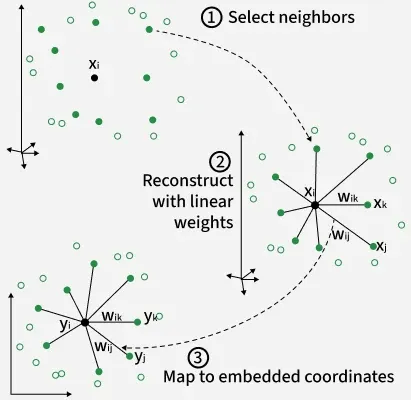

**Преимущества LLE:**
- Сохранение локальной структуры: Основное преимущество LLE заключается в его способности сохранять локальную структуру данных. Он эффективно отображает точки, которые были соседями в высокоразмерном пространстве, как соседей в низкоразмерном пространстве.

- Эффективность для нелинейных данных: В отличие от линейных методов, таких как PCA, LLE может обнаруживать и использовать нелинейные структуры в данных, что делает его подходящим для сложных многообразий.

- Не требует знания базового многообразия: LLE не требует предварительных знаний о форме или параметризации базового многообразия, на котором лежат данные.

- Простота реализации: Несмотря на математическую основу, концепция реконструкции из соседей относительно интуитивно понятна, и алгоритм может быть реализован достаточно прямолинейно.
- Инвариантность к сдвигу и масштабу: Алгоритм инвариантен к сдвигу (translation) и масштабу (scaling) данных, поскольку он работает с весами реконструкции, которые также инвариантны.

**Недостатки LLE:**
- Чувствительность к выбору числа соседей (k): Производительность LLE сильно зависит от правильного выбора гиперпараметра k (количество ближайших соседей). Слишком малое k может привести к разрывам в многообразии, а слишком большое — к сглаживанию локальных структур и потере нелинейной информации.

- Вычислительная сложность: Для больших наборов данных LLE может быть вычислительно затратным, особенно на шаге поиска ближайших соседей и нахождении собственных векторов большой матрицы (хотя для разреженных матриц это может быть быстрее).

- Чувствительность к шуму: LLE довольно чувствителен к шуму в данных. Шумные точки могут искажать локальные структуры и, как следствие, низкоразмерное представление.
- Проблемы с глобальной структурой: Хотя LLE хорошо сохраняет локальную структуру, он не всегда гарантирует оптимальное сохранение глобальной структуры данных.
- Ограничения для несвязных многообразий: LLE предполагает, что данные лежат на едином связном многообразии. Если многообразие состоит из нескольких несвязанных компонент, LLE может иметь проблемы с их адекватным представлением.

# 2. Classification with Sparse Features


In [1]:
!pip -q install optuna kaggle

In [43]:
import os
import time
import warnings
import struct
from array import array
from sklearn.exceptions import ConvergenceWarning
import numpy as np
import pandas as pd
import random
from scipy.sparse import csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.utils.extmath import randomized_svd
from sklearn.manifold import TSNE, locally_linear_embedding
import umap

import optuna
import cv2
import pickle
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

- Load the "Book Recommendation Dataset" (source).

In [3]:
!gdown 1jVvlykdSDdcOPb7eZyS7Cr6cj2lBlF1K # ratings
!gdown 1LITcIYQg8MAzwSwUE9MvELxGd-cchJg8 # users

Downloading...
From: https://drive.google.com/uc?id=1jVvlykdSDdcOPb7eZyS7Cr6cj2lBlF1K
To: /content/Ratings.csv
100% 22.6M/22.6M [00:00<00:00, 44.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LITcIYQg8MAzwSwUE9MvELxGd-cchJg8
To: /content/Users.csv
100% 11.0M/11.0M [00:00<00:00, 37.5MB/s]


In [4]:
users_data = pd.read_csv("Users.csv")
users_data.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
ratings_data = pd.read_csv("Ratings.csv")
ratings_data.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


- Create a matrix of user-book interactions. Using Sparse Matrices.

In [6]:
# preparation
user_book_interactions = pd.merge(ratings_data, users_data, on='User-ID', how='inner') # inner bc we need both rating and age
user_book_interactions.dropna(subset=['Age'], inplace=True)
user_book_interactions.reset_index(drop=True, inplace=True)
print('\nAfter merging and dropping NaN ages:\n')
display(user_book_interactions.head())

# mappings for User-ID and ISBN to integer indices
user_ids = user_book_interactions['User-ID'].unique()
isbns = user_book_interactions['ISBN'].unique()

user_to_idx = {user_id: i for i, user_id in enumerate(user_ids)}
isbn_to_idx = {isbn: i for i, isbn in enumerate(isbns)}

user_book_interactions['user_idx'] = user_book_interactions['User-ID'].map(user_to_idx)
user_book_interactions['book_idx'] = user_book_interactions['ISBN'].map(isbn_to_idx)
print('\nAfter mapping:\n')
display(user_book_interactions.head())
display(user_book_interactions.info())


After merging and dropping NaN ages:



,User-ID,ISBN,Book-Rating,Location,Age
0,276727,0446520802,0,"h, new south wales, australia",16.0
1,276729,052165615X,3,"rijeka, n/a, croatia",16.0
2,276729,0521795028,6,"rijeka, n/a, croatia",16.0
3,276733,2080674722,0,"paris, n/a, france",37.0
4,276737,0600570967,6,"sydney, new south wales, australia",14.0



After mapping:



,User-ID,ISBN,Book-Rating,Location,Age,user_idx,book_idx
0,276727,0446520802,0,"h, new south wales, australia",16.0,0,0
1,276729,052165615X,3,"rijeka, n/a, croatia",16.0,1,1
2,276729,0521795028,6,"rijeka, n/a, croatia",16.0,1,2
3,276733,2080674722,0,"paris, n/a, france",37.0,2,3
4,276737,0600570967,6,"sydney, new south wales, australia",14.0,3,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840288 entries, 0 to 840287
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   User-ID      840288 non-null  int64  
 1   ISBN         840288 non-null  object 
 2   Book-Rating  840288 non-null  int64  
 3   Location     840288 non-null  object 
 4   Age          840288 non-null  float64
 5   user_idx     840288 non-null  int64  
 6   book_idx     840288 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 44.9+ MB


None

In [7]:
# users as rows, books as columns, ratings as values
n_users = len(user_ids)
n_books = len(isbns)

# csr_matrix((data, (row_ind, col_ind)), [shape=(M, N)])
# where data, row_ind and col_ind satisfy the relationship a[row_ind[k], col_ind[k]] = data[k].
interaction_matrix = csr_matrix(
    (user_book_interactions['Book-Rating'],
     (user_book_interactions['user_idx'], user_book_interactions['book_idx'])),
    shape=(n_users, n_books)
)

print(f'\nShape of the user-book interaction matrix: {interaction_matrix.shape}')
print(f'Number of all stored values (including explicit 0): {interaction_matrix.nnz}')
print(f'Sparsity: {100 * (1 - interaction_matrix.nnz/ (interaction_matrix.shape[0] * interaction_matrix.shape[1])):.4f}%')

print('\nSparse matrix:')
pd.DataFrame(interaction_matrix[:5, :5].toarray())


Shape of the user-book interaction matrix: (62107, 285089)
Number of all stored values (including explicit 0): 840288
Sparsity: 99.9953%

Sparse matrix:


,0,1,2,3,4
0,0,0,0,0,0
1,0,3,6,0,0
2,0,0,0,0,0
3,0,0,0,0,6
4,0,0,0,0,0


In [8]:
y_age = user_book_interactions.groupby('User-ID')['Age'].first()
user_id_map_df = pd.DataFrame(list(user_to_idx.items()), columns=['User-ID', 'user_idx'])
isbn_map_df = pd.DataFrame(list(isbn_to_idx.items()), columns=['ISBN', 'book_idx'])

- Split the dataset into training, valid, and test parts.

In [9]:
user_age_df = pd.DataFrame({
    'User-ID': y_age.index,
    'Age': y_age.values
})

user_age_df = pd.merge(user_age_df, user_id_map_df, on='User-ID', how='inner')
user_age_df.sort_values(by='user_idx', inplace=True)
y = user_age_df['Age'].values

# 70-15-15 split
user_indices = np.arange(n_users)
train_user_idx, temp_user_idx = train_test_split(user_indices, test_size=0.3, random_state=21)
val_user_idx, test_user_idx = train_test_split(temp_user_idx, test_size=0.5, random_state=21)

# feature matrices (X) and target vectors (y) for each set
X_train = interaction_matrix[train_user_idx]
y_train = y[train_user_idx]

X_val = interaction_matrix[val_user_idx]
y_val = y[val_user_idx]

X_test = interaction_matrix[test_user_idx]
y_test = y[test_user_idx]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (43474, 285089), y_train shape: (43474,)
X_val shape: (9316, 285089), y_val shape: (9316,)
X_test shape: (9317, 285089), y_test shape: (9317,)


## Build linear and random forest models to predict user age based on user-book interactions. Do not forget to choose optimal parameters.




In [10]:
def calc_metrics(model_name: str, y_true, y_pred, fit_time=None):
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  metrics = {'Model': model_name, 'MAE': mae, 'R2': r2}
  if fit_time is not None:
    metrics['Fit Time (s)'] = fit_time
  return metrics

all_results_list = []

### Lasso

In [11]:
# linear baseline on sparse input (on usual crash by RAM)
lasso = Lasso(alpha=0.5, fit_intercept=True, max_iter=1000, random_state=21)

start_time = time.time()
lasso.fit(X_train, y_train)
end_time = time.time()
fit_time = end_time - start_time

y_pred = lasso.predict(X_val)
lasso_metrics = calc_metrics('Lasso Regression', y_val, y_pred, fit_time=fit_time)
all_results_list.append(lasso_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689


In [12]:
#def objective(trial):
#    params = {
#        'max_iter': trial.suggest_int('max_iter', 500, 1500),
#        'alpha': trial.suggest_float('alpha', 0.1, 10.0, log=True),
#        'tol': trial.suggest_float('tol', 1e-4, 1e-2, log=True),
#        'fit_intercept': True, # just hate False here
#        'precompute': False, # bc sparse input
#        'selection': trial.suggest_categorical('selection', ['cyclic', 'random']),
#        'random_state': 21,
#    }
#
#    model = Lasso(**params)
#
#    # np.nan in case of convergence warning
#    with warnings.catch_warnings():
#        warnings.filterwarnings('error', category=ConvergenceWarning)
#        try:
#            model.fit(X_train, y_train)
#        except ConvergenceWarning:
#            return np.nan
#
#    y_pred = model.predict(X_val)
#    score = r2_score(y_val, y_pred)
#    return score
#
#study = optuna.create_study(
#    direction='maximize',
#    study_name='lasso_optimization',
#    load_if_exists=True,
#    sampler=optuna.samplers.TPESampler(seed=21),
#    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
#)
#
#study.optimize(
#    objective,
#    n_trials=20,
#    timeout=3600,
#    show_progress_bar=True
#)
#
#print(f"\nBest trial:")
#trial = study.best_trial
#print(f"\nR2: {trial.value}")
#print(f"\nParams:")
#for key, value in trial.params.items():
#    print(f"{key}: {value}")

- Best trial:
R2: 0.0005031287020575981
- Params:

max_iter: 710

alpha: 0.10923007095278056

tol: 0.0007550230013537537

selection: cyclic

In [13]:
#lasso_best_params = study.best_trial.params
lasso_best_params = {'max_iter': 710, 'alpha': 0.10923007095278056, 'tol': 0.0007550230013537537, 'selection': 'cyclic'}
lasso = Lasso(**lasso_best_params)

start_time = time.time()
lasso.fit(X_train, y_train)
end_time = time.time()
fit_time = end_time - start_time

y_pred = lasso.predict(X_val)
lasso_metrics = calc_metrics('Optimized Lasso Regression', y_val, y_pred, fit_time=fit_time)
all_results_list.append(lasso_metrics)
all_results_df = pd.DataFrame(all_results_list)
all_results_df.head()

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293


### Forest

In [14]:
# forest baseline on sparse input
# with max_features='sqrt' fits fast
forest = RandomForestRegressor(n_estimators=5, criterion='squared_error', random_state=21, n_jobs=-1, max_depth=5, max_features='sqrt')

start_time = time.time()
forest.fit(X_train, y_train)
end_time = time.time()
fit_time = end_time - start_time

y_pred = forest.predict(X_val)
forest_metrics = calc_metrics('Forest Regression', y_val, y_pred, fit_time=fit_time)
all_results_list.append(forest_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073


In [15]:
#def objective(trial):
#    params = {
#        'n_estimators': trial.suggest_int('n_estimators', 5, 20),
#        'max_depth': trial.suggest_int('max_depth', 5, 15),
#        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
#        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 25),
#        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
#        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 50, 500),
#        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.05),
#        'max_samples': trial.suggest_float('max_samples', 0.7, 0.9),
#        'criterion': 'absolute_error',
#        'random_state': 21,
#        'n_jobs': -1,
#        'verbose': 0,
#    }
#
#    model = RandomForestRegressor(**params)
#
#    # np.nan in case of convergence warning
#    with warnings.catch_warnings():
#        warnings.filterwarnings('error', category=ConvergenceWarning)
#        try:
#            model.fit(X_train, y_train)
#        except ConvergenceWarning:
#            return np.nan
#
#    y_pred = model.predict(X_val)
#    score = r2_score(y_val, y_pred)
#    return score
#
#study = optuna.create_study(
#    direction='maximize',
#    study_name='forest_optimization',
#    load_if_exists=True,
#    sampler=optuna.samplers.TPESampler(seed=21),
#    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
#)
#
#study.optimize(
#    objective,
#    n_trials=20,
#    timeout=3600,
#    show_progress_bar=True
#)
#
#print(f"\nBest trial:")
#trial = study.best_trial
#print(f"\nR2: {trial.value}")
#print(f"\nParams:")
#for key, value in trial.params.items():
#    print(f"{key}: {value}")

- Best trial: R2: -0.027189680898933144
- Params:
n_estimators: 5
max_depth: 8
min_samples_split: 39
min_samples_leaf: 5
max_features: sqrt
max_leaf_nodes: 186
min_impurity_decrease: 0.033195514731235
max_samples: 0.7616228786473758

In [16]:
#forest_best_params = study.best_trial.params
forest_best_params = {'n_estimators': 5, 'max_depth': 8, 'min_samples_split': 39, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_leaf_nodes': 186, 'min_impurity_decrease': 0.033195514731235, 'max_samples': 0.7616228786473758}
forest = RandomForestRegressor(**forest_best_params)

start_time = time.time()
forest.fit(X_train, y_train)
end_time = time.time()
fit_time = end_time - start_time

y_pred = forest.predict(X_val)
forest_metrics = calc_metrics('Optimized Forest Regression', y_val, y_pred, fit_time=fit_time)
all_results_list.append(forest_metrics)
all_results_df = pd.DataFrame(all_results_list)
all_results_df.head()

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565


## Use PCA and UMAP to reduce the dimensionality of the features.
## Build linear model and random forest model on the compressed features.

In [17]:
# PCA - 35s
n_components_to_try = 100
pca_model = PCA(n_components=n_components_to_try, random_state=21, whiten=True, svd_solver='arpack')
X_train_pca = pca_model.fit_transform(X_train)

In [18]:
# UMAP - 6min
n_components_to_try = 100
reducer = umap.UMAP(n_components=n_components_to_try , n_neighbors=10, min_dist=0.1, n_jobs=-1)
X_train_umap = reducer.fit_transform(X_train)

### Lasso + PCA

In [19]:
lasso_pca = Lasso(**lasso_best_params)

X_val_pca = pca_model.transform(X_val) # X_val_pca

start_time_lasso_pca = time.time()
lasso_pca.fit(X_train_pca, y_train)
end_time_lasso_pca = time.time()
fit_time_lasso_pca = end_time_lasso_pca - start_time_lasso_pca

y_pred_lasso_pca = lasso_pca.predict(X_val_pca)

lasso_pca_metrics = calc_metrics('Optimized Lasso Regression + PCA', y_val, y_pred_lasso_pca, fit_time=fit_time_lasso_pca)
all_results_list.append(lasso_pca_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565
4,Optimized Lasso Regression + PCA,11.538788,0.002760,0.129489


### Forest + PCA

In [20]:
forest_pca = RandomForestRegressor(**forest_best_params)

start_time_forest_pca = time.time()
forest_pca.fit(X_train_pca, y_train)
end_time_forest_pca = time.time()
fit_time_forest_pca = end_time_forest_pca - start_time_forest_pca

y_pred_forest_pca = forest_pca.predict(X_val_pca)

forest_pca_metrics = calc_metrics('Optimized Forest Regression + PCA', y_val, y_pred_forest_pca, fit_time=fit_time_lasso_pca)
all_results_list.append(forest_pca_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565
4,Optimized Lasso Regression + PCA,11.538788,0.002760,0.129489
5,Optimized Forest Regression + PCA,11.328173,0.025704,0.129489


### Lasso + UMAP

In [21]:
lasso_umap = Lasso(**lasso_best_params)

X_val_umap = reducer.transform(X_val) # X_val_umap

start_time_lasso_umap = time.time()
lasso_umap.fit(X_train_umap, y_train)
end_time_lasso_umap = time.time()
fit_time_lasso_umap = end_time_lasso_umap - start_time_lasso_umap

y_pred_lasso_umap = lasso_umap.predict(X_val_umap)

lasso_umap_metrics = calc_metrics('Optimized Lasso Regression + UMAP', y_val, y_pred_lasso_umap, fit_time=fit_time_lasso_pca)
all_results_list.append(lasso_umap_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565
4,Optimized Lasso Regression + PCA,11.538788,0.002760,0.129489
5,Optimized Forest Regression + PCA,11.328173,0.025704,0.129489
6,Optimized Lasso Regression + UMAP,11.554588,0.000106,0.129489


### Forest + UMAP

In [22]:
forest_umap = RandomForestRegressor(**forest_best_params)

start_time_forest_umap = time.time()
forest_umap.fit(X_train_umap, y_train)
end_time_forest_umap = time.time()
fit_time_forest_umap = end_time_forest_umap - start_time_forest_umap

y_pred_forest_umap = forest_umap.predict(X_val_umap)

forest_umap_metrics = calc_metrics('Optimized Forest Regression + UMAP', y_val, y_pred_forest_umap, fit_time=fit_time_lasso_pca)
all_results_list.append(forest_umap_metrics)
all_results_df = pd.DataFrame(all_results_list)
display(all_results_df)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565
4,Optimized Lasso Regression + PCA,11.538788,0.002760,0.129489
5,Optimized Forest Regression + PCA,11.328173,0.025704,0.129489
6,Optimized Lasso Regression + UMAP,11.554588,0.000106,0.129489
7,Optimized Forest Regression + UMAP,11.553130,-0.002725,0.129489


## Compare fitting time and quality for models from iv and vi.

In [23]:
# display final table with results
display(all_results_df)
all_results_df.to_csv('task1_final_table.csv', index=False)

,Model,MAE,R2,Fit Time (s)
0,Lasso Regression,11.556439,-0.000002,19.834689
1,Optimized Lasso Regression,11.553433,0.000503,40.264293
2,Forest Regression,11.553030,0.000096,0.483073
3,Optimized Forest Regression,11.555690,0.000181,0.127565
4,Optimized Lasso Regression + PCA,11.538788,0.002760,0.129489
5,Optimized Forest Regression + PCA,11.328173,0.025704,0.129489
6,Optimized Lasso Regression + UMAP,11.554588,0.000106,0.129489
7,Optimized Forest Regression + UMAP,11.553130,-0.002725,0.129489


- В случае как PCA, так и UMAP наблюдали более быстрое обучение модели, что связано с уменьшением размерности датасета в ходе применения данных алгоритмов.
- По метрике MAE все модели примерно одинаковы плохи; по метрике r2 тоже, но есть лидер - Optimized Forest Regression + PCA.
- PCA по сравнению с UMAP сильнее улучшило метрику r2, что связано с работой самого алгоритма: PCA максимизирует сохраненную дисперсию, а коэффициент детерминации по определению измеряет долю объясненной дисперсии целевой переменной.




# 3. Visualizations

- Load the MNIST dataset

In [24]:
!gdown 18nYLfWLBAa5oj76XtRp7L_7EJEhFkDCJ # images
!gdown 1YAkrXVhrEZd13jSnLpJHdVfJ8v73Bywb # labels

Downloading...
From: https://drive.google.com/uc?id=18nYLfWLBAa5oj76XtRp7L_7EJEhFkDCJ
To: /content/train-images.idx3-ubyte
100% 47.0M/47.0M [00:00<00:00, 112MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YAkrXVhrEZd13jSnLpJHdVfJ8v73Bywb
To: /content/train-labels.idx1-ubyte
100% 60.0k/60.0k [00:00<00:00, 3.73MB/s]


In [25]:
def read_images(images_filepath, labels_filepath):
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            labels = array("B", file.read())

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img

        return images, labels

In [26]:
images_filepath = "/content/train-images.idx3-ubyte"
labels_filepath = "/content/train-labels.idx1-ubyte"
X_train, Y_train = read_images(images_filepath, labels_filepath)

- Represent each digit image as a vector.

In [27]:
#X_train[0] # 28*28, list of 28 np.array

In [28]:
X_train_vectorized = []
for image_list in X_train:
    image_2d = np.array(image_list)
    X_train_vectorized.append(image_2d.flatten())

X_train_vectorized = np.array(X_train_vectorized)

print(f"Original X_train shape (first image): {np.array(X_train[0]).shape}")
print(f"Vectorized X_train shape: {X_train_vectorized.shape}")
print(f"Shape of the first vectorized image: {X_train_vectorized[0].shape}")

Original X_train shape (first image): (28, 28)
Vectorized X_train shape: (60000, 784)
Shape of the first vectorized image: (784,)


In [29]:
X_train_vectorized[0].shape

(784,)

- Transform vectors up to 2 dimensions using PCA, SVD, Randomized-SVD, TSNE, UMAP, and LLE.

In [30]:
# PCA
n_components_to_try = 2
pca_model = PCA(n_components=n_components_to_try, random_state=21, svd_solver='auto')
X_train_pca = pca_model.fit_transform(X_train_vectorized)
X_train_pca.shape

(60000, 2)

In [31]:
# SVD - можно truncated, потому что фулл будет считать все 784 собств значения
n_components_to_try = 2
svd_model = TruncatedSVD(n_components=n_components_to_try,
                         random_state=21,
                         algorithm='arpack')
X_train_svd = svd_model.fit_transform(X_train_vectorized)
X_train_svd.shape

(60000, 2)

In [32]:
# Randomized-SVD
# algorithm = 'randomized' in TruncatedSVD
svd_model = TruncatedSVD(n_components=n_components_to_try,
                         random_state=21,
                         algorithm='randomized')
X_train_svd_rand1 = svd_model.fit_transform(X_train_vectorized)
X_train_svd_rand1.shape

(60000, 2)

In [33]:
# Randomized-SVD
# separate implemetation of randomized - returns a tuple of (U, s, Vh)
n_components_to_try = 2
U, s, Vh = randomized_svd(M = X_train_vectorized,
                                   n_components=n_components_to_try,
                                   random_state=21)

X_train_svd_rand2 = U[:, :n_components_to_try] @ np.diag(s[:n_components_to_try])

X_train_svd_rand2.shape

(60000, 2)

In [34]:
# tSNE - too slow
#from sklearn.manifold import TSNE
#n_components_to_try = 2
#tsne_model = TSNE(n_components=n_components_to_try,
#                  random_state=21,
#                  perplexity=30, #neighbors
#                  metric='euclidean',
#                  init='pca',
#                  method='barnes_hut' #apprx with O(nlogn)
#                  )
#X_train_tsne = tsne_model.fit_transform(X_train_vectorized)
#X_train_tsne.shape

In [35]:
# tSNE - subsample,  2 min
sample_fraction = 0.2
X_subsample, _, Y_subsample, _ = train_test_split(
    X_train_vectorized, Y_train,
    train_size=sample_fraction,
    random_state=21,
    stratify=Y_train
)

n_components_to_try = 2
tsne_model_subsampled = TSNE(n_components=n_components_to_try,
                               random_state=21,
                               perplexity=15,
                               metric='euclidean',
                               init='pca',
                               method='barnes_hut',
                               max_iter=1000,
                               n_jobs=-1
                               )

X_train_tsne = tsne_model_subsampled.fit_transform(X_subsample)
X_train_tsne.shape

(12000, 2)

In [36]:
# UMAP
n_components_to_try = 2
umap_model = umap.UMAP(n_components=n_components_to_try, n_neighbors=10, min_dist=0.1, n_jobs=-1)
X_train_umap = umap_model.fit_transform(X_train_vectorized)
umap_model.embedding_ = X_train_umap
X_train_umap.shape

(60000, 2)

In [37]:
# LLE - subsample too
n_components_to_try = 2
X_train_lle, _ = locally_linear_embedding(X = X_subsample,
                                          n_neighbors=10,
                                          n_components = n_components_to_try,
                                          eigen_solver='auto',
                                          method='standard',
                                          n_jobs=-1
                                          )
X_train_lle.shape

(12000, 2)

- Propose metrics and compare models based on how well they separate digit classes.

- метрика - Silhoette score

S = (b-a) / max(a,b)

для каждой точки рассчитывает:
- a - среднее расстояние до других точек в своем кластере
- b - среднее расстояние до точек в ближайшем другом кластере

In [38]:
results_for_visualization_and_metrics = []

# PCA
results_for_visualization_and_metrics.append(('PCA', X_train_pca, Y_train))

# SVD
results_for_visualization_and_metrics.append(('SVD', X_train_svd, Y_train))

# Randomized-SVD (using TruncatedSVD)
results_for_visualization_and_metrics.append(('Randomized-SVD (TruncatedSVD)', X_train_svd_rand1, Y_train))

# Randomized-SVD (using randomized_svd function)
results_for_visualization_and_metrics.append(('Randomized-SVD (randomized_svd)', X_train_svd_rand2, Y_train))

# UMAP
results_for_visualization_and_metrics.append(('UMAP', X_train_umap, Y_train))

# LLE (subsampled data)
results_for_visualization_and_metrics.append(('LLE_subsampled', X_train_lle, Y_subsample))

# t-SNE (subsampled data)
results_for_visualization_and_metrics.append(('t-SNE_subsampled', X_train_tsne, Y_subsample))

In [39]:
def calc_sil_score(results:list):
  silhouette_scores = []

  for method_name, data, labels in results:
      if 'subsampled' in method_name:
          current_labels = Y_subsample
      else:
          current_labels = Y_train


      score = silhouette_score(data, current_labels)
      silhouette_scores.append({'Method': method_name, 'Silhouette Score': score})

  silhouette_df = pd.DataFrame(silhouette_scores)
  print("Silhouette Scores for each model:")
  display(silhouette_df)
  return silhouette_df

In [40]:
sil_df = calc_sil_score(results_for_visualization_and_metrics)

Silhouette Scores for each model:


,Method,Silhouette Score
0,PCA,0.023479
1,SVD,-0.028255
2,Randomized-SVD (TruncatedSVD),-0.028256
3,Randomized-SVD (randomized_svd),-0.028256
4,UMAP,0.540690
5,LLE_subsampled,0.046574
6,t-SNE_subsampled,0.332857


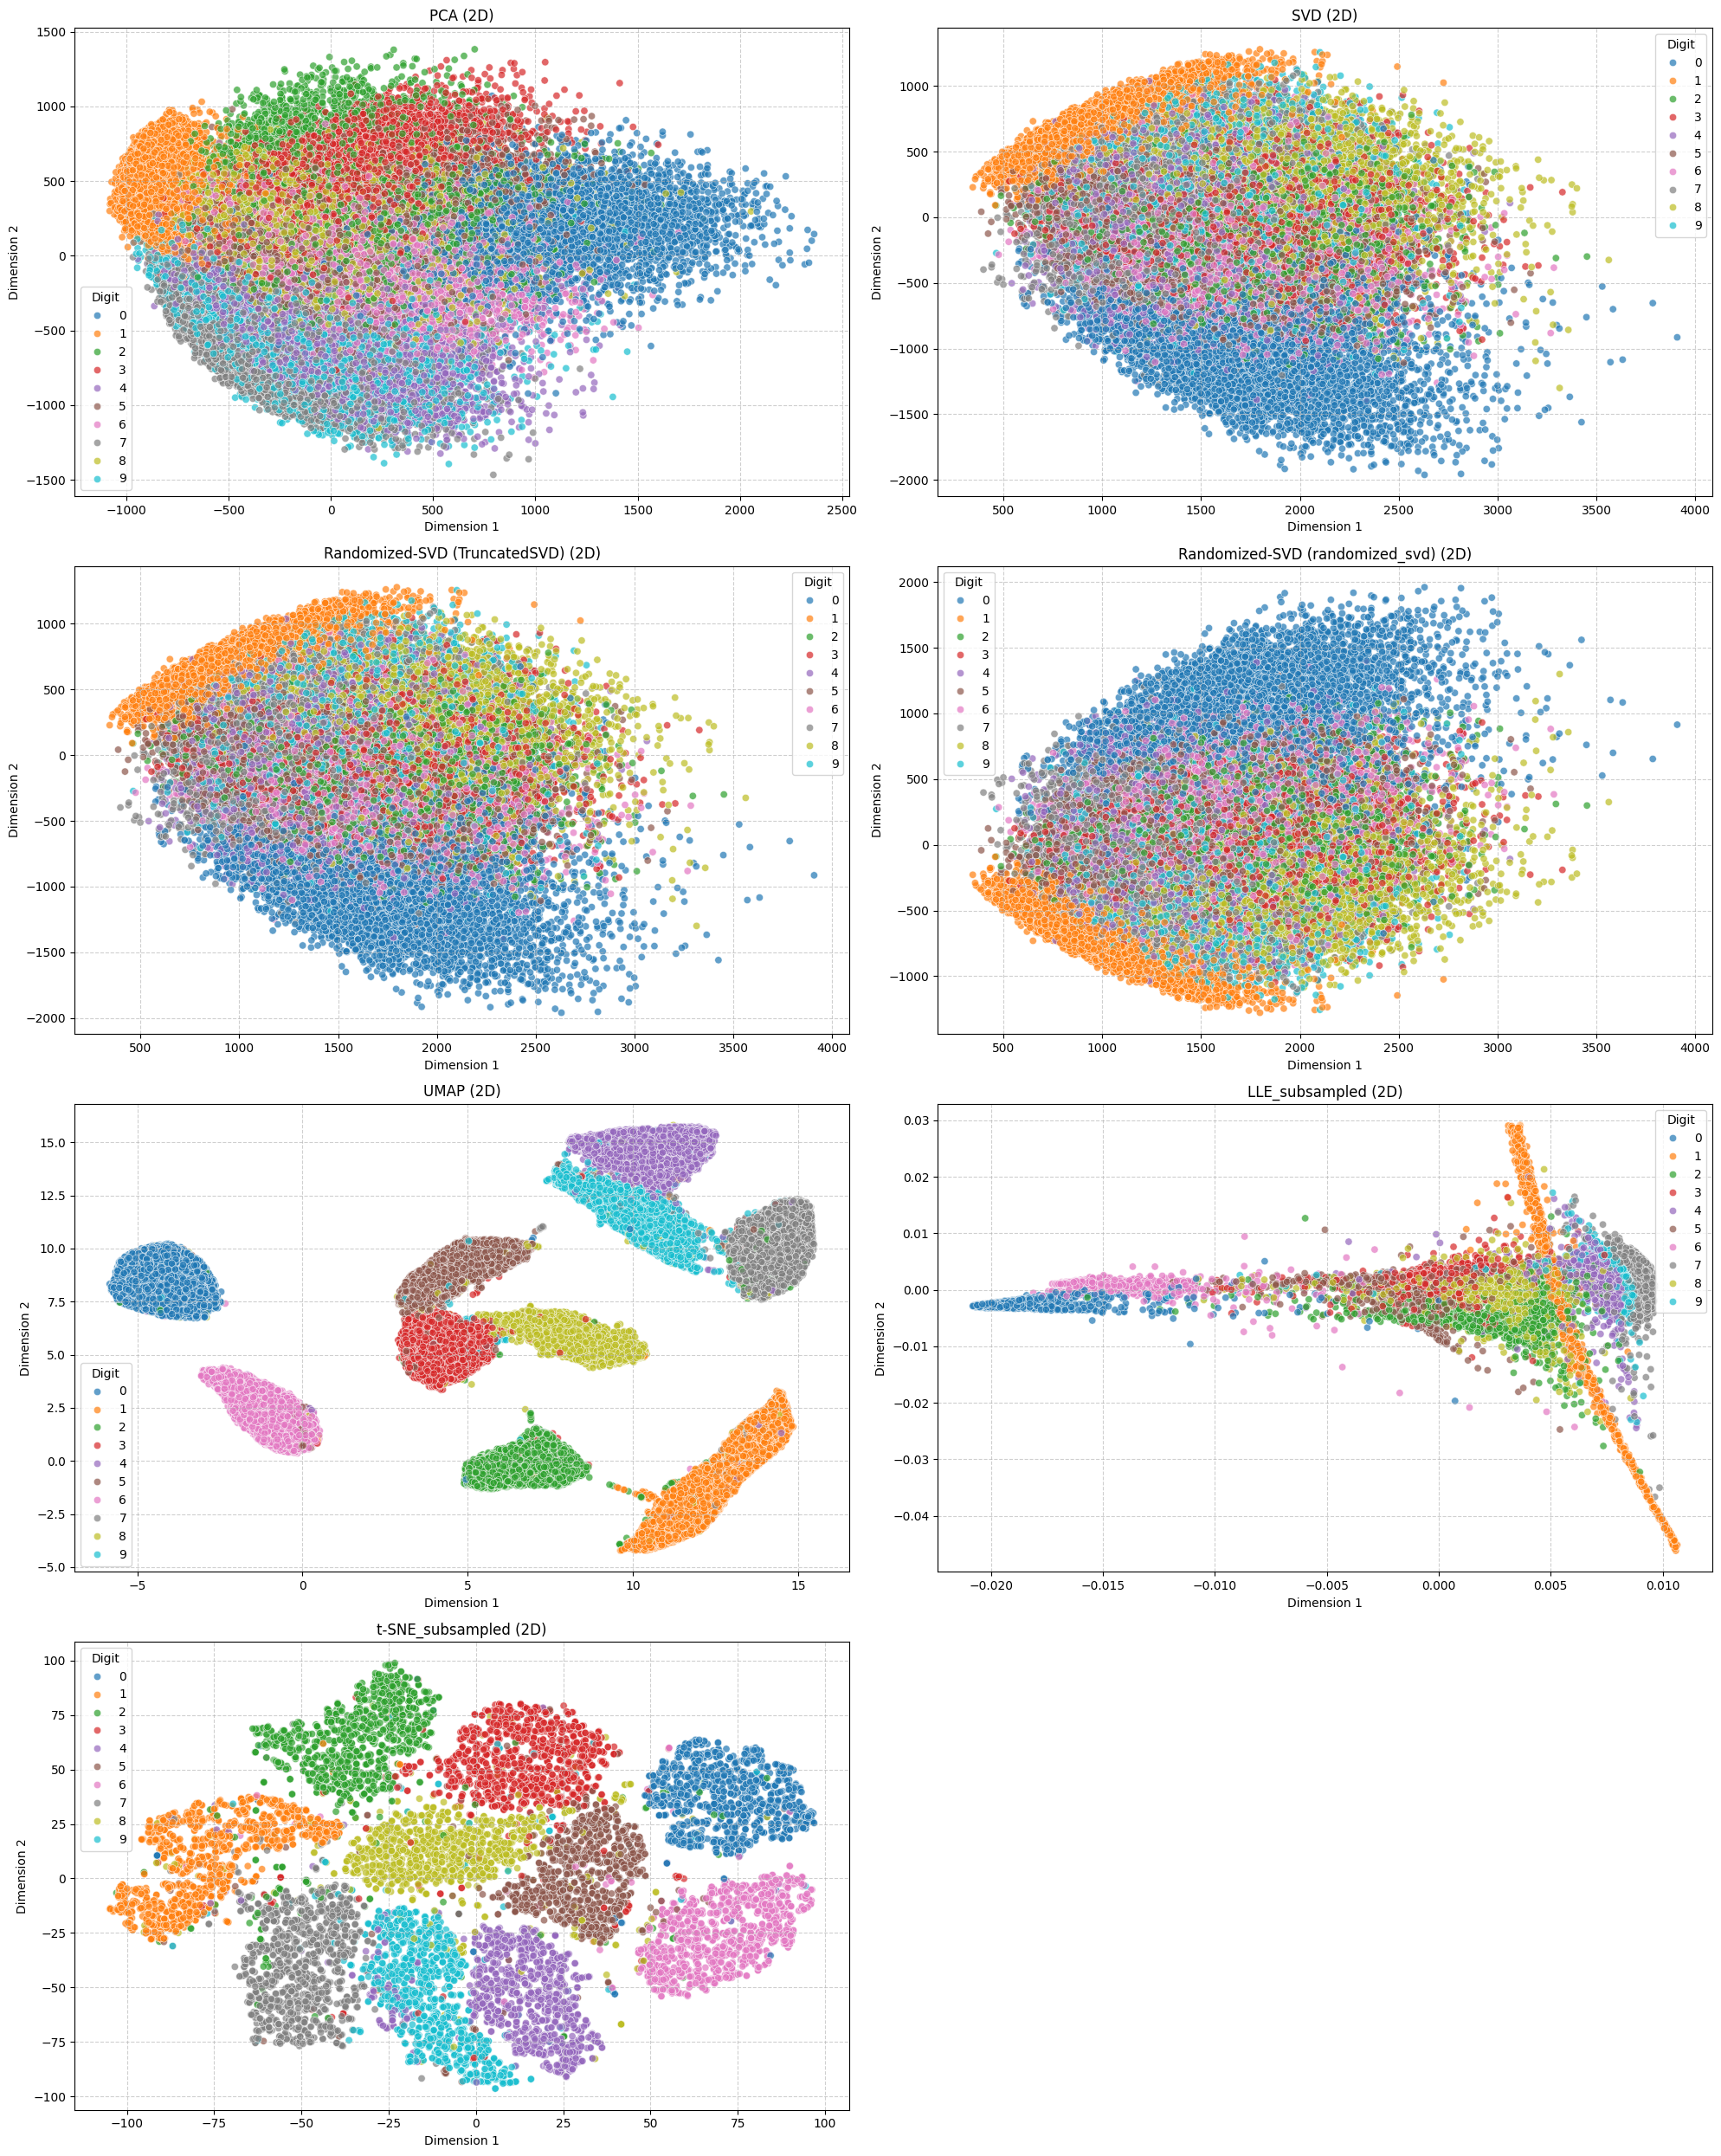

In [41]:
plt.figure(figsize=(20, 25))
for i, (method_name, data, labels) in enumerate(results_for_visualization_and_metrics):
    ax = plt.subplot(4, 2, i + 1)
    current_labels = np.array(labels)
    df_plot = pd.DataFrame({'Dim1': data[:, 0], 'Dim2': data[:, 1], 'Digit': current_labels})

    sns.scatterplot(x='Dim1', y='Dim2', hue='Digit', data=df_plot,
                    palette=sns.color_palette('tab10', n_colors=10),
                    legend='full', alpha=0.7,
                    ax=ax)
    ax.set_title(f'{method_name} (2D)')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

- По метрике Silhoette-score лучшее разделение обеспечивает UMAP (0.5), за ним идет tSNE_subsampled (0.33)
- По визуализациям лучшие разделения также получаются у UMAP и tSNE, те у методов-представителей обучения через многообразия. По-видимому, в датасете много нелинейных зависимостей, которые только вычислительно сложные нелинейные методы могут уловить.
- Стоит отметить, что UMAP - это оптимизированный вариант tSNE. Ключевое отличие UMAP в том, что он строит **взвешенный граф соседств**, где ребра существуют не между всеми точками, а только между **n_neighbors ближайшими соседями** для каждой точки. Это делает его вычисления более эффективными и детерминированными на этом этапе. В t-SNE же «близость» вероятностная и учитывает всех соседей, но с экспоненциально убывающим весом.

# 3. extra

- Save one of the models from the "Visualizations" part of the task.
- Your peer will load it and use it to compress one of the handwritten digits. The compressed vector should have the same values.
- Prepare code snippet that demonstate how to load, how to apply and what results should be.

In [44]:
# save model
filename = "pca_mnist_model.pkl"
pca_model_data = {
    'pca_model': pca_model,
    'n_components': 2,
    'original_shape': (28, 28),
    'components': pca_model.components_,
    'mean': pca_model.mean_,
    'explained_variance_ratio': pca_model.explained_variance_ratio_
}
with open(filename, 'wb') as f:
    pickle.dump(pca_model_data, f)

test_sample = {
    'original_image': X_train_vectorized[0],
    'original_label': Y_train[0],
    'compressed_vector': X_train_pca[0]
}

with open("test_sample.pkl", 'wb') as f:
    pickle.dump(test_sample, f)

In [45]:
# load model
with open("pca_mnist_model.pkl", 'rb') as f:
    model_data = pickle.load(f)

with open("test_sample.pkl", 'rb') as f:
    test_sample = pickle.load(f)

pca_model = model_data['pca_model']
original_image = test_sample['original_image']
stored_compressed = test_sample['compressed_vector']

In [46]:
new_compressed = pca_model.transform(original_image.reshape(1, -1))[0]
print(f"Цифра: {test_sample['original_label']}")
print(f"Сохранённый вектор: {stored_compressed}")
print(f"Новый вектор:{new_compressed}")
match = np.allclose(stored_compressed, new_compressed, rtol=1e-10, atol=1e-10)
print(f"\nСовпадают: {match}")

Цифра: 5
Сохранённый вектор: [123.93258866 312.67426202]
Новый вектор:[123.93258866 312.67426202]

Совпадают: True


- PCA детерминирован - совпадают точно (для UMAP не совпадали бы)

# 4. Image compression using SVD

- Select 3 random grayscale images and load them into matrix using Python.

In [47]:
X_train, Y_train = read_images(images_filepath, labels_filepath)
first_image_data = X_train[0] # orig - list of 28 arrays
image_2d = np.array(first_image_data) # 2d-array
image_vector = image_2d.flatten() # 1d vector

In [48]:
def prepare_image_matrices(X_train, Y_train, random_indices):
    individual_image_matrices = []
    individual_image_labels = []
    for idx in random_indices:
        image_2d = np.array(X_train[idx])
        label = Y_train[idx]
        individual_image_matrices.append(image_2d)
        individual_image_labels.append(label)
    return individual_image_matrices, individual_image_labels

def visualize_images(image_matrices, image_labels, num_images_to_select, suptitle_text='Selected Grayscale Images'):
    plt.figure(figsize=(10, 3))
    for i, (image_2d, label) in enumerate(zip(image_matrices, image_labels)):
        plt.subplot(1, num_images_to_select, i + 1)
        plt.imshow(image_2d, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(suptitle_text)
    plt.subplots_adjust(top=0.75)
    plt.show()

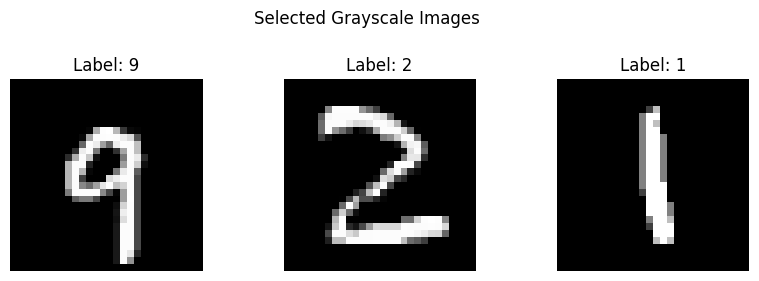

In [49]:
random.seed(21)
num_images_to_select = 3
random_indices = random.sample(range(len(X_train_vectorized)), num_images_to_select)


individual_image_matrices, individual_image_labels = prepare_image_matrices(X_train, Y_train, random_indices)

visualize_images(individual_image_matrices, individual_image_labels, num_images_to_select)

image_matrix_1 = individual_image_matrices[0]
image_matrix_2 = individual_image_matrices[1]
image_matrix_3 = individual_image_matrices[2]


In [50]:
print(image_matrix_1.shape)
print(image_matrix_2.shape)
print(image_matrix_3.shape)

(28, 28)
(28, 28)
(28, 28)


- Decompose the matrix using SVD.
- Vary the rank, compute a low-rank approximation of the original matrix, and plot the recovered image. Use up to 10 different ranks.

In [51]:
def plot_image_approximations(original_image, image_name, ranks_to_try, suptitle_text='SVD Approximations'):
    U, s, Vh = np.linalg.svd(original_image, full_matrices=False)

    plt.figure(figsize=(15, 6))
    plt.suptitle(suptitle_text, fontsize=16)

    for i, rank_k in enumerate(ranks_to_try):
        M_k_approx = U[:, :rank_k] @ np.diag(s[:rank_k]) @ Vh[:rank_k, :]

        plt.subplot(2, 5, i + 1)
        plt.imshow(M_k_approx, cmap='gray')
        plt.title(f'Rank = {rank_k}')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    return s

In [52]:
def plot_singular_value_spectrum(singular_values, image_name, optimal_rank=None):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(singular_values) + 1), singular_values, marker='o', linestyle='-')
    plt.title(f'Singular Value Spectrum for {image_name}')
    plt.xlabel('Singular Value Index')
    plt.ylabel('Singular Value')
    plt.grid(True)
    plt.yscale('log')

    if optimal_rank is not None:
        plt.axvline(x=optimal_rank, color='r', linestyle='--', label=f'Optimal Rank = {optimal_rank}')
        plt.legend()

    plt.show()

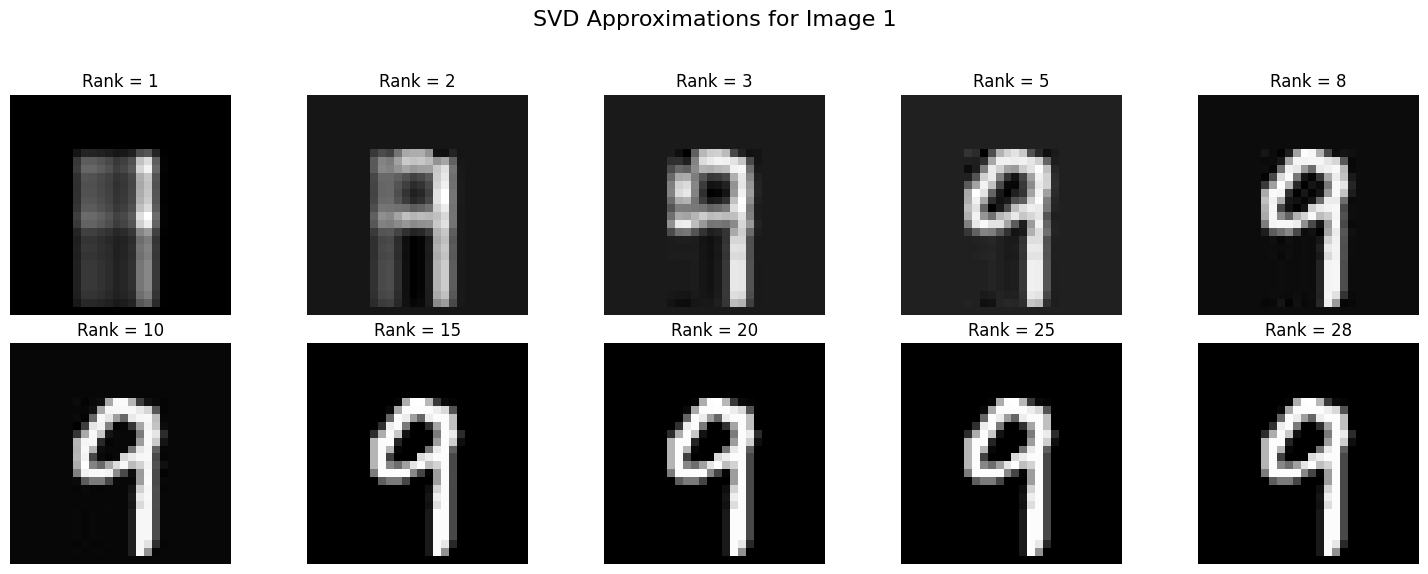

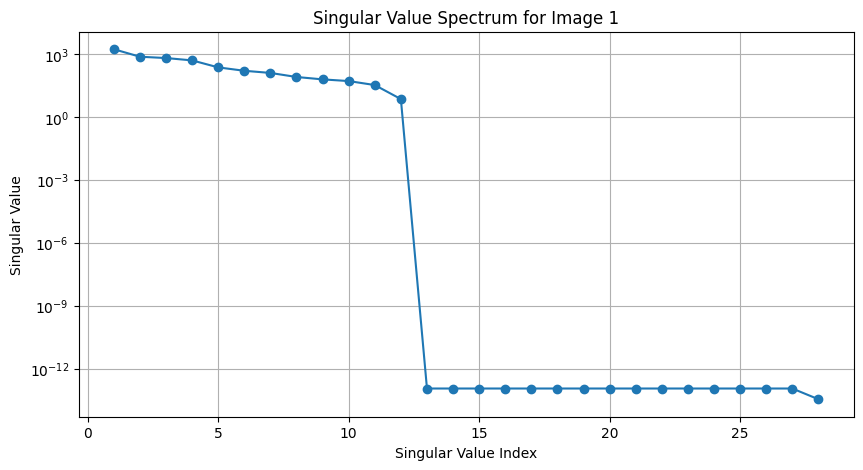

In [53]:
ranks_to_try = [1, 2, 3, 5, 8, 10, 15, 20, 25, 28]

s1 = plot_image_approximations(image_matrix_1, 'Image 1', ranks_to_try, 'SVD Approximations for Image 1')
plot_singular_value_spectrum(s1, 'Image 1')

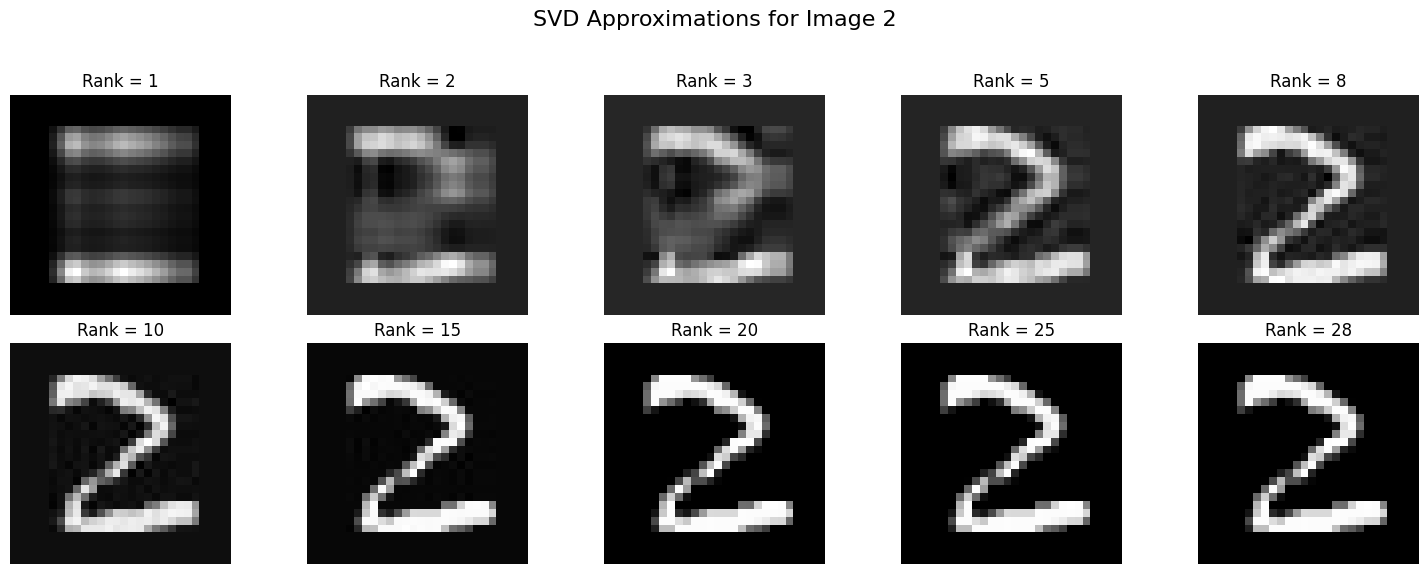

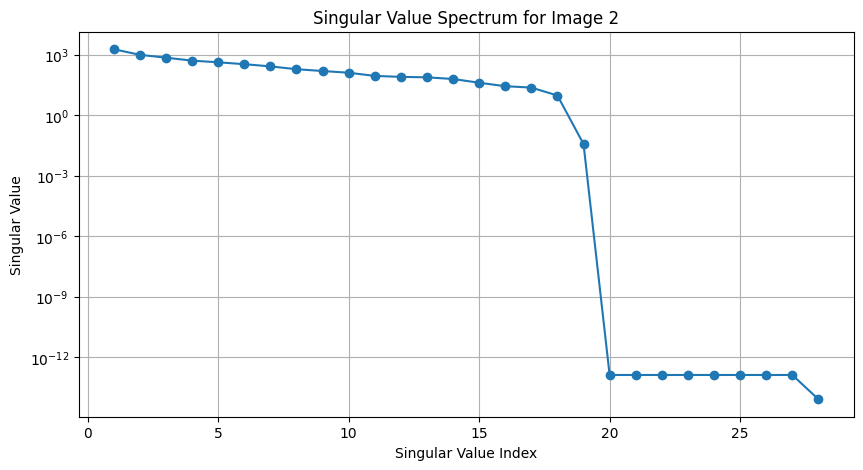

In [54]:
s2 = plot_image_approximations(image_matrix_2, 'Image 2', ranks_to_try, 'SVD Approximations for Image 2')
plot_singular_value_spectrum(s2, 'Image 2')

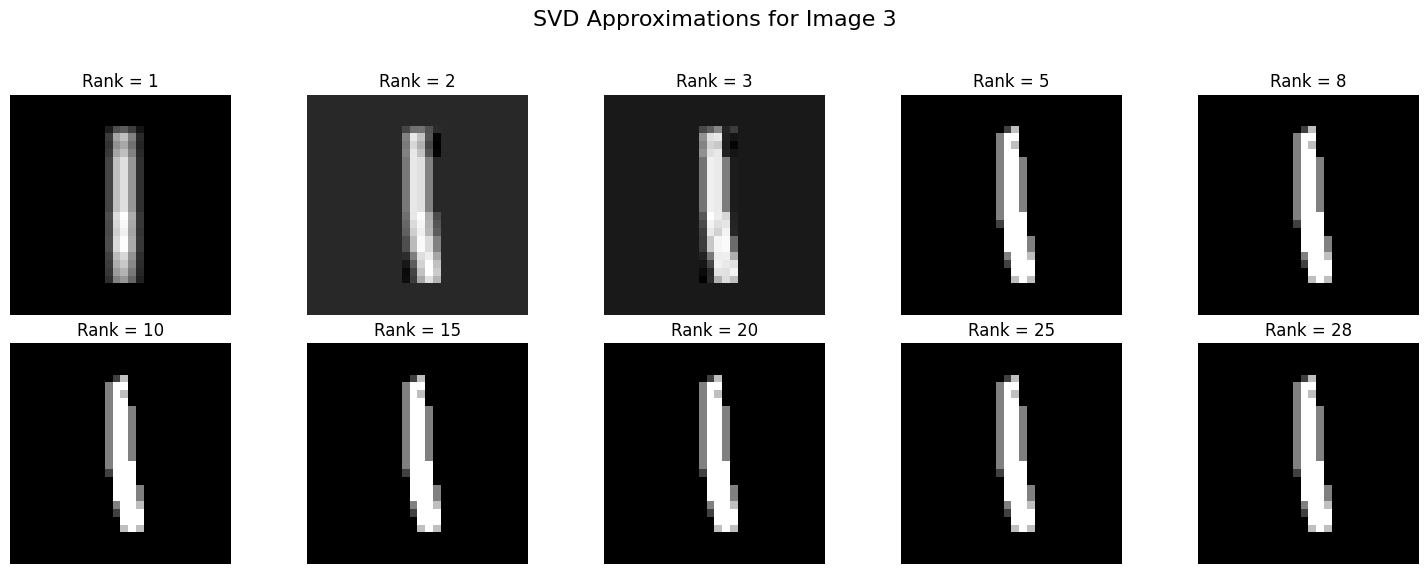

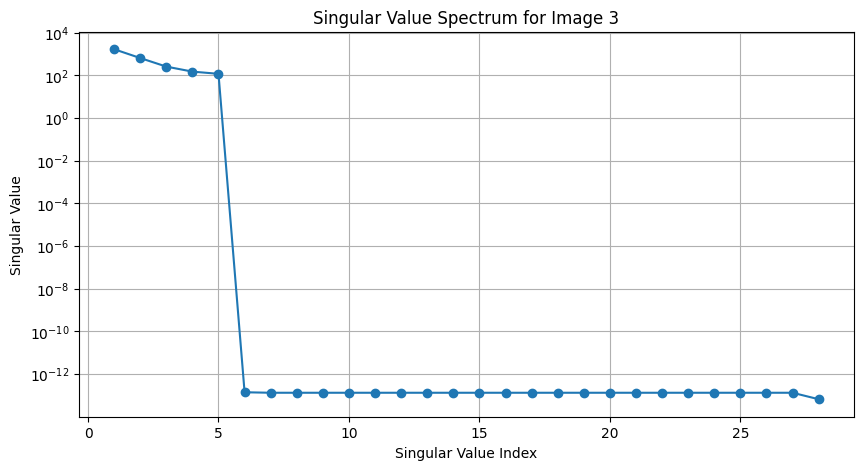

In [55]:
s3 = plot_image_approximations(image_matrix_3, 'Image 3', ranks_to_try, 'SVD Approximations for Image 3')
plot_singular_value_spectrum(s3, 'Image 3')

### What does the singular value spectrum look like and how many modes are needed for good image reconstruction?

- **Спектр сингулярных чисел** для всех трёх изображений показывает быстрый спад первых значений с последующим медленным затуханием. Это указывает на высокую сжимаемость данных.

- Основная информация (дисперсия) содержится в малом числе компонент (мод), особенно в первых 5-10.

### **Эффективность реконструкции для разных рангов**:

- Ранг 1-3: Восстановленные изображения размыты, но основная форма цифры видна. Доминирующие признаки уже уловлены.

- Ранг 5-10: Качество значительно улучшается, цифра становится хорошо узнаваемой. Этот диапазон часто достаточен для "хорошей" реконструкции.

- Ранг 15-20: Восстановление почти идеально, детали сохранены. Оптимальный баланс между сжатием и качеством.

- Ранг 25-28: Реконструкция полная и визуально идентичная оригиналу.

### Вывод:
- Для "хорошего" восстановления изображений MNIST (чётко узнаваемая цифра) достаточно 5-15 компонент. Для практически идеального результата стоит использовать 15-20 компонент. Резкий изгиб ("локоть") в спектре сингулярных чисел показывает оптимальный порог для низкоранговой аппроксимации.

### Plot the distribution of explained variance versus rank. Explain what "explained variance" is.

- **Объясненная дисперсия** (explained variance) - доля от общей дисперсии исходных данных, которая описывается подмножеством сингулярных значений и соответствующих им сингулярных векторов.

- В процессе сингулярного разложения (SVD), когда матрица $A$ раскладывается на $A = U\Sigma V^T$, сингулярные значения ($s_i$) в диагональной матрице $\Sigma$ отражают «силу» или «важность» каждого отдельного сингулярного компонента (или моды) в объяснении вариативности исходных данных.

- **Квадраты сингулярных значений ($s_i^2$)**: пропорциональны объему дисперсии, описываемой каждым отдельным сингулярным компонентом.

- **Общая(полная) дисперсия**: Сумма квадратов всех сингулярных  значений s ($\sum s_i^2$).

- **Доля объясненной дисперсии для ранга $k$**: Эта доля показывает, какую часть общей дисперсии объясняют первые $k$ сингулярных значений:

  $$ \text{Explained Variance Ratio}_k = \frac{\sum_{i=1}^{k} s_i^2}{\sum_{i=1}^{n} s_i^2} $$

где $n$ - общее количество сингулярных значений (эквивалентно min(rows, columns)).

In [56]:
def plot_spectrum(data, x_label, y_label, title, y_scale='linear'):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(data) + 1), data, marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if y_scale == 'log':
        plt.yscale('log')
    plt.grid(True)
    plt.show()

In [57]:
def plot_explained_variance_and_insights(singular_values, image_name):
    total_variance = np.sum(singular_values**2)
    explained_variance_ratio = (singular_values**2) / total_variance
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    plot_spectrum(
        cumulative_explained_variance,
        x_label='SVD Rank (Number of Singular Values)',
        y_label='Cumulative Explained Variance Ratio',
        title=f'Cumulative Explained Variance vs. SVD Rank for {image_name}'
    )

    # 95% 99% explained variance
    rank_95_percent = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1
    rank_99_percent = np.where(cumulative_explained_variance >= 0.99)[0][0] + 1

    print(f"\nData for {image_name}:")
    print(f"Для объяснения 95% дисперсии, примерно {rank_95_percent} сингулярных значений необходимо.")
    print(f"Для объяснения 99% дисперсии, примерно {rank_99_percent} сингулярных значений необходимо.")


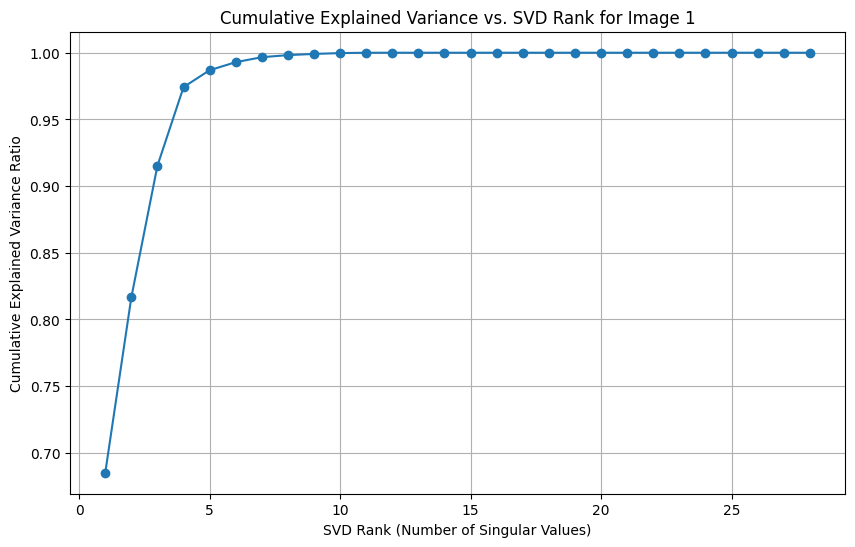


Data for Image 1:
Для объяснения 95% дисперсии, примерно 4 сингулярных значений необходимо.
Для объяснения 99% дисперсии, примерно 6 сингулярных значений необходимо.


In [58]:
plot_explained_variance_and_insights(s1, 'Image 1')

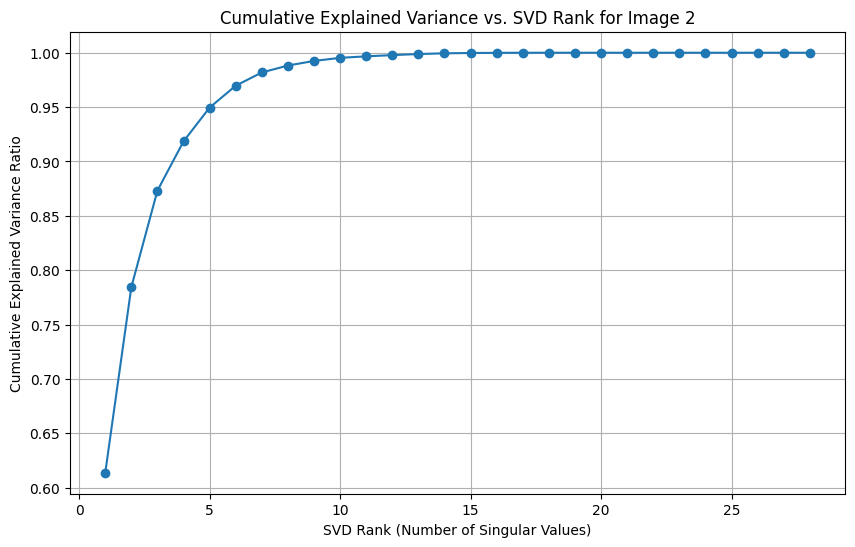


Data for Image 2:
Для объяснения 95% дисперсии, примерно 6 сингулярных значений необходимо.
Для объяснения 99% дисперсии, примерно 9 сингулярных значений необходимо.


In [59]:
plot_explained_variance_and_insights(s2, 'Image 2')

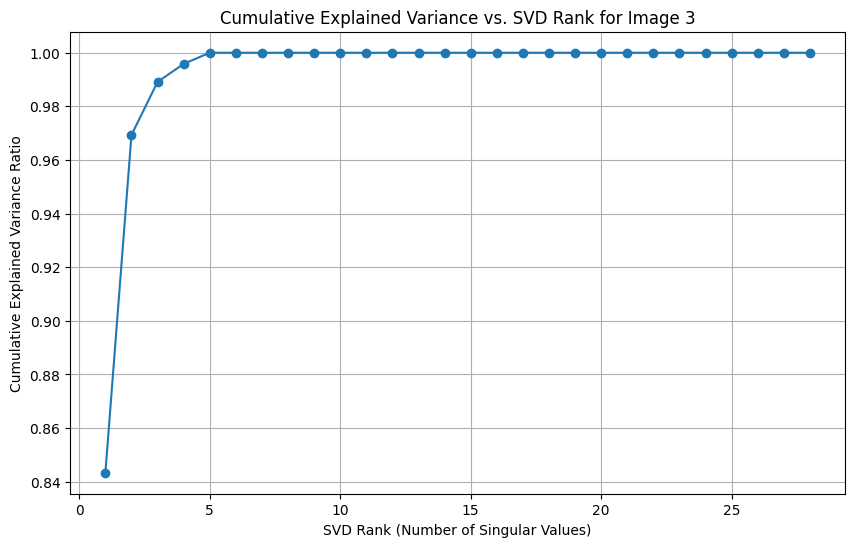


Data for Image 3:
Для объяснения 95% дисперсии, примерно 2 сингулярных значений необходимо.
Для объяснения 99% дисперсии, примерно 4 сингулярных значений необходимо.


In [60]:
plot_explained_variance_and_insights(s3, 'Image 3')

# 5. Background detection using SVD


- Load "Video_008.avi" (source — bmc_real.zip).
- Represent the video as a matrix and decompose it using SVD.
- Reconstruct the first frame using low-rank approximation. What rank should you use to get the background?

In [61]:
!gdown 1MLDzKqRigMLAk2ag3ZHQkg3ZKTT10dtr # video_008

Downloading...
From: https://drive.google.com/uc?id=1MLDzKqRigMLAk2ag3ZHQkg3ZKTT10dtr
To: /content/Video_008.avi
100% 3.18M/3.18M [00:00<00:00, 25.4MB/s]


In [62]:
video_path = '/content/Video_008.avi'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
else:
    print(f"Successfully opened video file {video_path}")
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame.flatten())

    cap.release()
    video_matrix = np.array(frames)
    print(video_matrix.shape)

Successfully opened video file /content/Video_008.avi
(792, 76800)


In [63]:
def plot_video_frame_approximations(U, s, Vh, frame_idx, original_frame, frame_dims, ranks_to_try, suptitle_text='SVD Approximations of a Video Frame'):

    plt.figure(figsize=(15, 6))
    plt.suptitle(suptitle_text, fontsize=16)

    # orig frame
    plt.subplot(2, 6, 1) # number of ranks + orig
    plt.imshow(original_frame.reshape(frame_dims), cmap='gray')
    plt.title(f'Original Frame {frame_idx}')
    plt.axis('off')

    for i, rank_k in enumerate(ranks_to_try):
        # to rank_k
        M_k_approx_full_video = U[:, :rank_k] @ np.diag(s[:rank_k]) @ Vh[:rank_k, :]
        # frame_idx
        reconstructed_frame = M_k_approx_full_video[frame_idx, :]

        plt.subplot(2, 6, i + 2)
        plt.imshow(reconstructed_frame.reshape(frame_dims), cmap='gray')
        plt.title(f'Rank {rank_k}')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### График сингулярных чисел:

- Наблюдается резкий спад первых 5-10 сингулярных значений, что указывает на высокую сжимаемость видео.

- Основная доля информации (дисперсии) сосредоточена в малом числе компонент (мод).

- Низкие ранги (1-3) захватывают фон. Постоянный или медленно меняющийся фон вносит основной вклад в общую дисперсию, поэтому он описывается первыми, самыми мощными сингулярными компонентами.

- Высокие ранги захватывают движение и шум. Динамичные объекты (передний план) и шум меняются от кадра к кадру, поэтому их вклад распределён по многим компонентам с малыми сингулярными числами.

- Белую машину становится видно примерно с 64 ранга, например.

- Можно попробовать найти оптимальный ранг по точке перегиба:

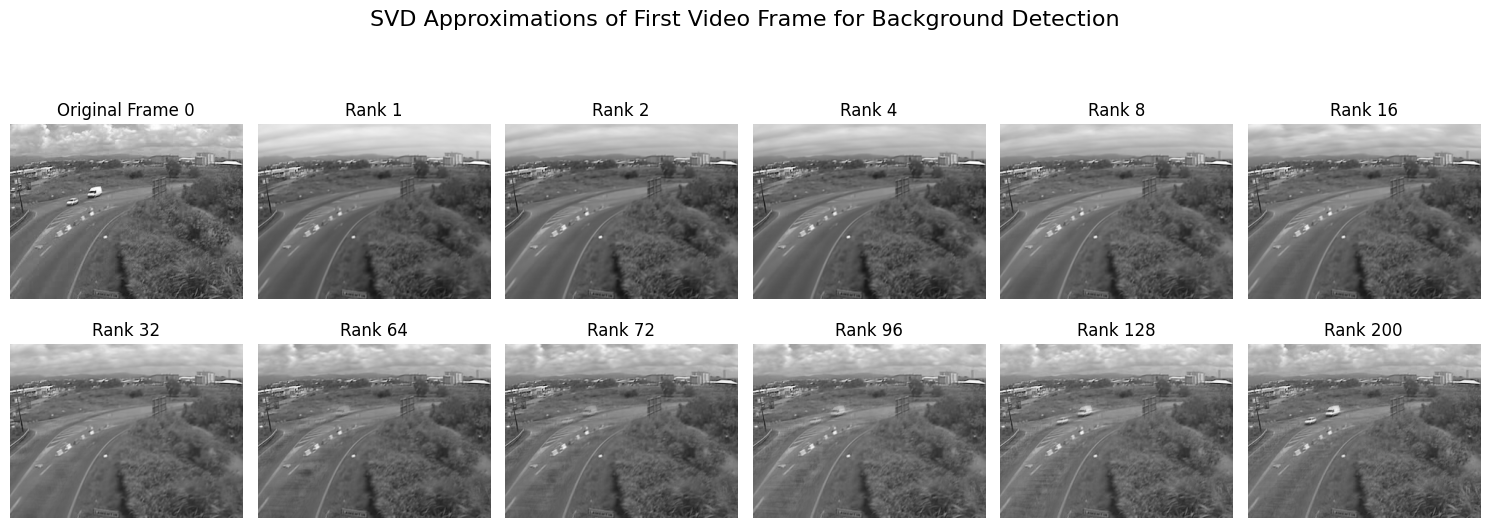

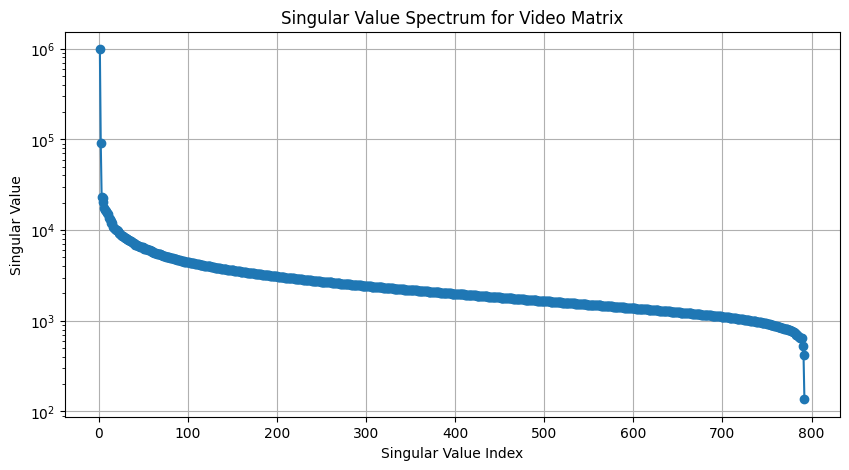

In [64]:
# frame dimensions (240x320 for 76800 pixels)
frame_height = 240
frame_width = 320
frame_dims = (frame_height, frame_width)

ranks_to_try = [1, 2, 4, 8, 16, 32, 64, 72, 96, 128, 200]
U_video, s_video, Vh_video = np.linalg.svd(video_matrix, full_matrices=False)

first_frame_idx = 0
original_first_frame = video_matrix[first_frame_idx]

plot_video_frame_approximations(
    U_video, s_video, Vh_video,
    first_frame_idx, original_first_frame,
    frame_dims, ranks_to_try,
    suptitle_text='SVD Approximations of First Video Frame for Background Detection'
)

plot_singular_value_spectrum(s_video, 'Video Matrix')

Optimal rank for background detection: 2


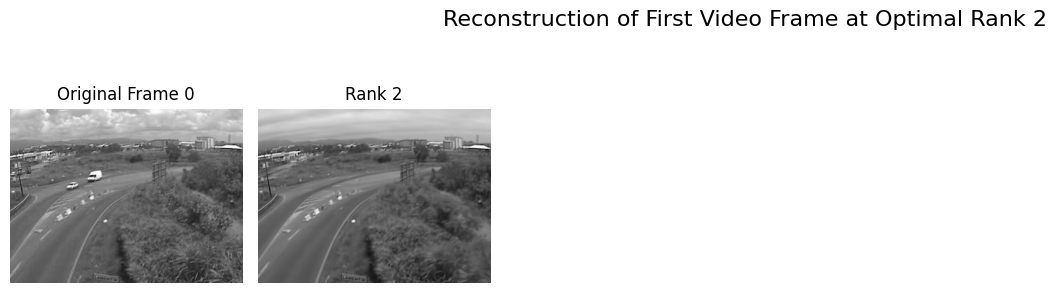

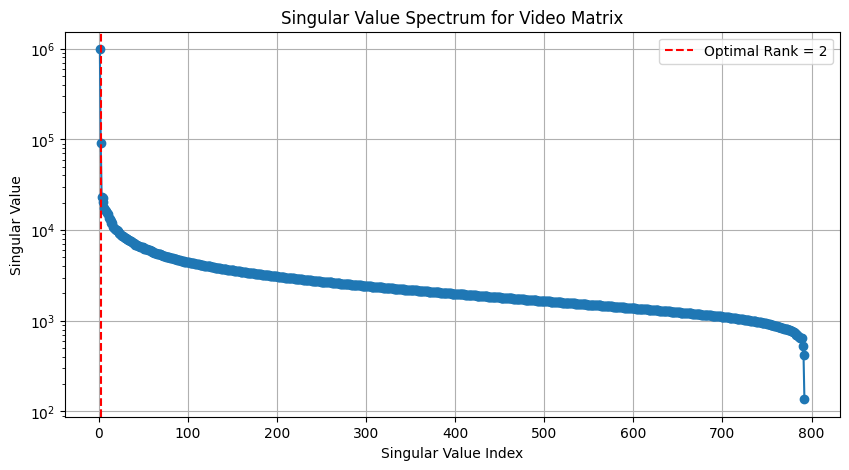

In [65]:
def find_optimal_rank_inflection(singular_values):
    first_diff = np.diff(singular_values)
    second_diff = np.diff(first_diff)
    optimal_rank_idx = np.argmax(second_diff) + 2

    return optimal_rank_idx

optimal_rank_video = find_optimal_rank_inflection(s_video)
print(f"Optimal rank for background detection: {optimal_rank_video}")

plot_video_frame_approximations(
    U_video, s_video, Vh_video,
    first_frame_idx, original_first_frame,
    frame_dims, [optimal_rank_video],
    suptitle_text=f'Reconstruction of First Video Frame at Optimal Rank {optimal_rank_video}'
)


plot_singular_value_spectrum(s_video, 'Video Matrix', optimal_rank=optimal_rank_video)

# 6. Bonus Part

- Using the face expression recognition dataset, fit the dimensionality reduction model to compress faces. Using the representations, try to turn a sad face into a smiley face and vice versa.

- Загружаем датасет

In [66]:
path = kagglehub.dataset_download("jonathanoheix/face-expression-recognition-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-expression-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/face-expression-recognition-dataset


In [67]:
base_dataset_path = path
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

images_data = []
labels = []

for emotion_idx, emotion in enumerate(emotions):
    for subset in ['train']:
        emotion_path = os.path.join(base_dataset_path, 'images', subset, emotion)
        if os.path.exists(emotion_path):
            for img_file in os.listdir(emotion_path):
                img_path = os.path.join(emotion_path, img_file)
                img = cv2.imread(img_path)
                if img is not None:
                    # 48x48
                    img_resized = cv2.resize(img, (48, 48))
                    # grayscale
                    gray_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
                    images_data.append(gray_img)
                    labels.append(emotion_idx)
                else:
                    print(f"Warning: Could not load image {img_path}")
        else:
            print(f"Warning: Path not found {emotion_path}")

print(f"Loaded {len(images_data)} images and {len(labels)} labels.")
X_faces = np.array(images_data)
y_faces = np.array(labels)

print(f"X_faces shape: {X_faces.shape}")
print(f"y_faces shape: {y_faces.shape}")

Loaded 28821 images and 28821 labels.
X_faces shape: (28821, 48, 48)
y_faces shape: (28821,)


- Смотрим рандомные изображения

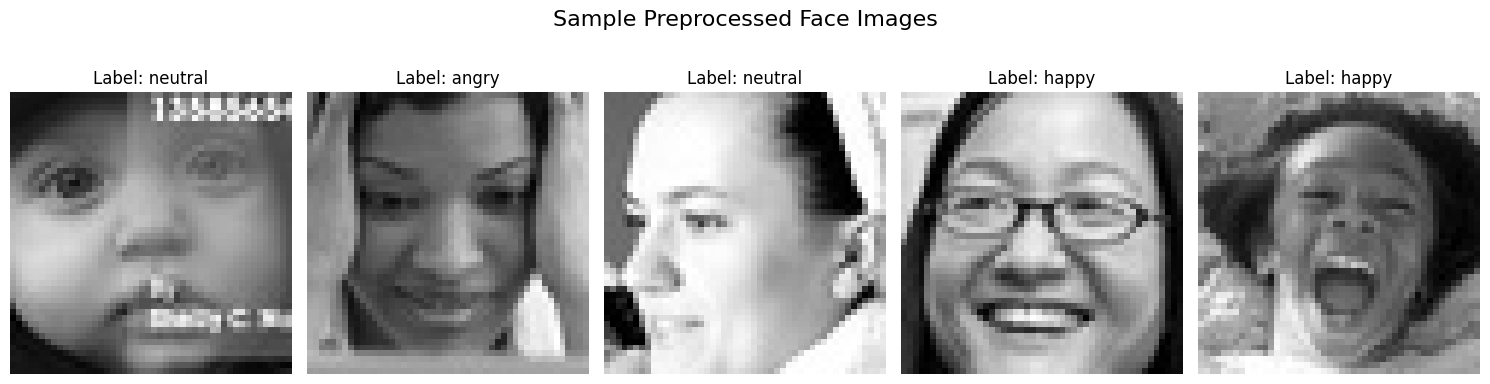

In [68]:
emotion_names = {i: emotion for i, emotion in enumerate(emotions)}
num_samples = 5
random_indices = np.random.choice(len(X_faces), num_samples, replace=False)

plt.figure(figsize=(15, 4))
plt.suptitle('Sample Preprocessed Face Images', fontsize=16)

for i, idx in enumerate(random_indices):
    image_2d = X_faces[idx]  # 48x48
    label_idx = y_faces[idx]
    emotion_name = emotion_names[label_idx]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image_2d, cmap='gray')
    plt.title(f'Label: {emotion_name}')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

- Идентифицируем грустные и веселые изображения

In [69]:
sad_label = emotions.index('sad')
happy_label = emotions.index('happy')
neutral_label = emotions.index('neutral')

print(f"Label for 'sad': {sad_label}")
print(f"Label for 'happy': {happy_label}")

sad_mask = (y_faces == sad_label)
happy_mask = (y_faces == happy_label)
neutral_mask = (y_faces == neutral_label)

filtered_mask = sad_mask | happy_mask | neutral_mask

X_filtered_faces = X_faces[filtered_mask]
y_filtered_labels = y_faces[filtered_mask]

print(f"Original X_faces shape: {X_faces.shape}")
print(f"Filtered X_faces shape (sad neutral happy): {X_filtered_faces.shape}")
print(f"Filtered y_faces shape (sad neutral happy): {y_filtered_labels.shape}")

Label for 'sad': 5
Label for 'happy': 3
Original X_faces shape: (28821, 48, 48)
Filtered X_faces shape (sad neutral happy): (17084, 48, 48)
Filtered y_faces shape (sad neutral happy): (17084,)


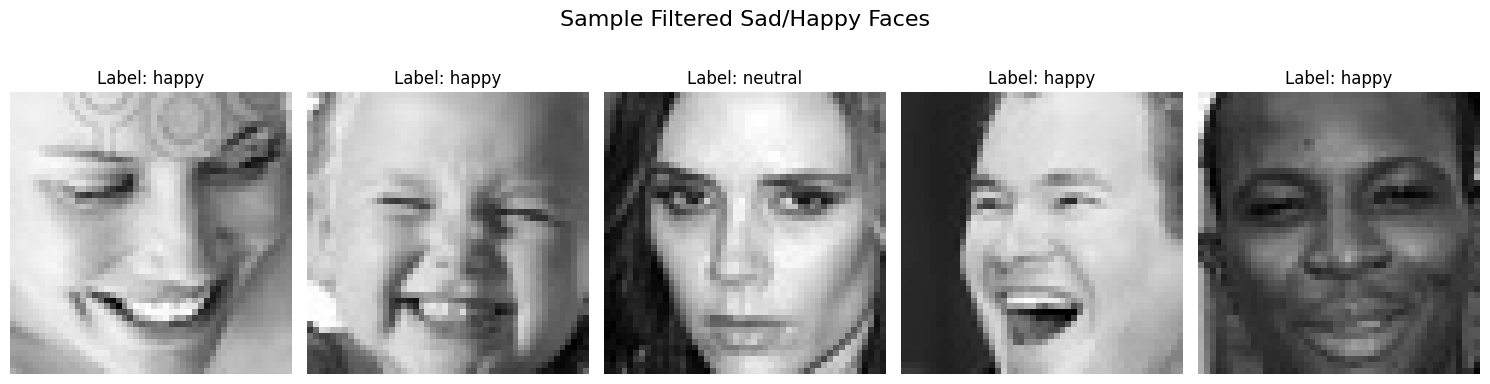

In [70]:
num_samples = 5
random_indices_filtered = np.random.choice(len(X_filtered_faces), num_samples, replace=False)

plt.figure(figsize=(15, 4))
plt.suptitle('Sample Filtered Sad/Happy Faces', fontsize=16)

for i, idx in enumerate(random_indices_filtered):
    image_2d = X_filtered_faces[idx]
    label_idx = y_filtered_labels[idx]
    emotion_name = emotions[label_idx]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image_2d, cmap='gray')
    plt.title(f'Label: {emotion_name}')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

- Используем PCA на happy & sad faces

In [82]:
X_filtered_faces_flattened = X_filtered_faces.reshape(X_filtered_faces.shape[0], -1)
n_components_faces = 1000
pca_faces_model = PCA(n_components=n_components_faces, random_state=21, svd_solver='auto')
X_faces_pca = pca_faces_model.fit_transform(X_filtered_faces_flattened)
X_faces_pca.shape

(17084, 1000)

- Находим "средний" вектор улыбки и грусти, полученный после применения PCA

In [83]:
sad_faces_pca = X_faces_pca[y_filtered_labels == sad_label]
mean_sad_face_pca = np.mean(sad_faces_pca, axis=0)

happy_faces_pca = X_faces_pca[y_filtered_labels == happy_label]
mean_happy_face_pca = np.mean(happy_faces_pca, axis=0)

neutral_faces_pca = X_faces_pca[y_filtered_labels == neutral_label]
mean_neutral_face_pca = np.mean(neutral_faces_pca, axis=0)


print(f"Shape of mean_sad_face_pca: {mean_sad_face_pca.shape}")
print(f"Shape of mean_happy_face_pca: {mean_happy_face_pca.shape}")
print(f"Shape of mean_neutral_face_pca: {mean_neutral_face_pca.shape}")

Shape of mean_sad_face_pca: (1000,)
Shape of mean_happy_face_pca: (1000,)
Shape of mean_neutral_face_pca: (1000,)


In [84]:
smile_vector = mean_happy_face_pca -  mean_sad_face_pca
print(f"Shape of smile_vector: {smile_vector.shape}")

Shape of smile_vector: (1000,)


In [85]:
def reconstruct_face(pca_components, pca_model, original_shape=(48, 48)):
    reconstructed_flattened = pca_model.inverse_transform(pca_components)
    reconstructed_face = reconstructed_flattened.reshape(original_shape)
    return reconstructed_face

def visualize_face_transformation(original_sad_face, original_happy_face,
                                  transformed_sad_to_happy, transformed_happy_to_sad,
                                  sad_label, happy_label):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(original_sad_face, cmap='gray')
    plt.title(f'Original Sad Face')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(transformed_sad_to_happy, cmap='gray')
    plt.title('Sad to Happy Transformation')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(original_happy_face, cmap='gray')
    plt.title(f'Original Happy Face')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(transformed_happy_to_sad, cmap='gray')
    plt.title('Happy to Sad Transformation')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

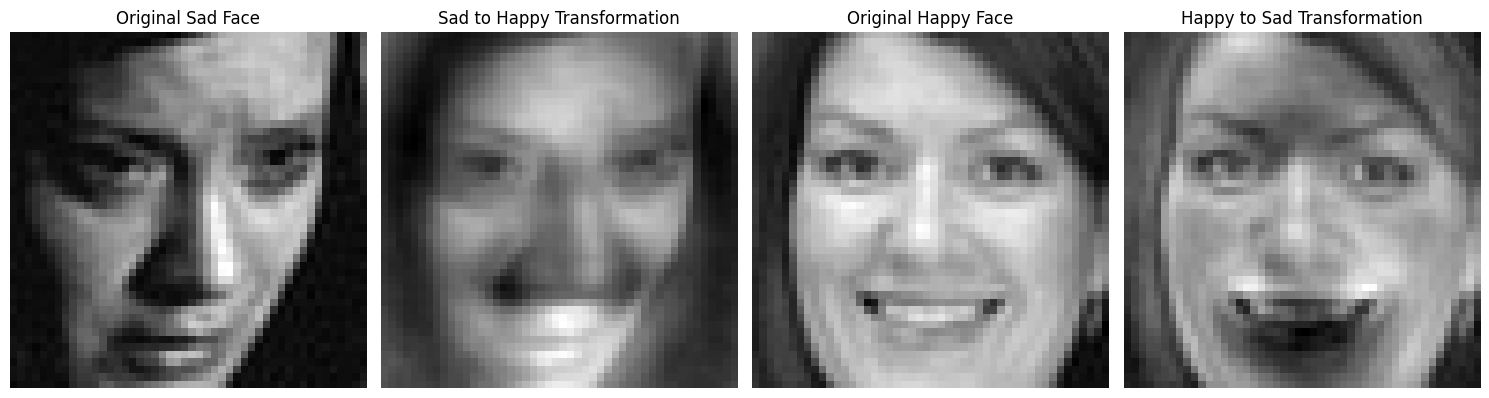

In [86]:
np.random.seed(21)
random_sad_idx = np.random.choice(np.where(y_filtered_labels == sad_label)[0])
random_happy_idx = np.random.choice(np.where(y_filtered_labels == happy_label)[0])

original_sad_face = X_filtered_faces[random_sad_idx]
original_happy_face = X_filtered_faces[random_happy_idx]
original_sad_face_flattened = X_filtered_faces_flattened[random_sad_idx]
original_happy_face_flattened = X_filtered_faces_flattened[random_happy_idx]

sad_face_pca_components = pca_faces_model.transform(original_sad_face_flattened.reshape(1, -1))[0]
happy_face_pca_components = pca_faces_model.transform(original_happy_face_flattened.reshape(1, -1))[0]

transformation_factor1 = 7.0  #
transformation_factor2 = 7.0  #
transformed_sad_to_happy_pca = sad_face_pca_components + transformation_factor1 * smile_vector
transformed_happy_to_sad_pca = happy_face_pca_components - transformation_factor2 * smile_vector


transformed_sad_to_happy_face = reconstruct_face(transformed_sad_to_happy_pca, pca_faces_model)
transformed_happy_to_sad_face = reconstruct_face(transformed_happy_to_sad_pca, pca_faces_model)

original_sad_face_reconstructed = reconstruct_face(sad_face_pca_components, pca_faces_model)
original_happy_face_reconstructed = reconstruct_face(happy_face_pca_components, pca_faces_model)

visualize_face_transformation(
    original_sad_face_reconstructed,
    original_happy_face_reconstructed,
    transformed_sad_to_happy_face,
    transformed_happy_to_sad_face,
    sad_label,
    happy_label
)

- выглядит не очень, попробуем автоэнкодер.

In [76]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

X_normalized = X_filtered_faces.astype('float32') / 255.0
# (num_samples, 48, 48, 1)
X_normalized = np.expand_dims(X_normalized, axis=-1)
X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, y_filtered_labels, test_size=0.1, random_state=42
)
latent_dim = 512

#encoder_inputs = keras.Input(shape=(48, 48, 1))
#x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_inputs)
#x = layers.MaxPooling2D((2, 2), padding='same')(x)      # 24x24
#x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#x = layers.MaxPooling2D((2, 2), padding='same')(x)      # 12x12
#x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#x = layers.MaxPooling2D((2, 2), padding='same')(x)      # 6x6
#x = layers.Flatten()(x)
#x = layers.Dense(512, activation='relu')(x)
#x = layers.Dropout(0.2)(x)
#encoder_outputs = layers.Dense(latent_dim, activation='linear')(x)
#encoder = keras.Model(encoder_inputs, encoder_outputs, name='encoder')
#
#decoder_inputs = keras.Input(shape=(latent_dim,))
#x = layers.Dense(512, activation='relu')(decoder_inputs)
#x = layers.Dropout(0.2)(x)
#x = layers.Dense(6 * 6 * 128, activation='relu')(x)
#x = layers.Reshape((6, 6, 128))(x)
#x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
#x = layers.UpSampling2D((2, 2))(x)                      # 12x12
#x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
#x = layers.UpSampling2D((2, 2))(x)                      # 24x24
#x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
#x = layers.UpSampling2D((2, 2))(x)                      # 48x48
#decoder_outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
#decoder = keras.Model(decoder_inputs, decoder_outputs, name='decoder')
#
## autoencoder = enc + dec
#autoencoder_inputs = encoder_inputs
#autoencoder_outputs = decoder(encoder(encoder_inputs))
#autoencoder = keras.Model(autoencoder_inputs, autoencoder_outputs, name='autoencoder')
#
#autoencoder.compile(
#    optimizer=keras.optimizers.Adam(learning_rate=0.001),
#    loss='mse'
#)
#
#autoencoder.summary()
#
#
#history = autoencoder.fit(
#    X_train, X_train,
#    epochs=80,
#    batch_size=32,
#    validation_data=(X_val, X_val),
#    callbacks=[
#        keras.callbacks.EarlyStopping(
#            monitor='val_loss',
#            patience=10,
#            restore_best_weights=True
#        ),
#        keras.callbacks.ReduceLROnPlateau(
#            monitor='val_loss',
#            factor=0.5,
#            patience=5,
#            min_lr=1e-6
#        )
#    ],
#    verbose=1
#)
## fig 1
#plt.figure(figsize=(8, 4))
#plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
#plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
#plt.xlabel('Epoch')
#plt.ylabel('Loss (MSE)')
#plt.legend()
#plt.title('Training History')
#plt.grid(True, alpha=0.3)
#plt.tight_layout()
#plt.show()
#
## fig 2
#plt.figure(figsize=(12, 5))
#n_test = 5
#test_indices = np.random.choice(len(X_val), n_test, replace=False)
#
#for i, idx in enumerate(test_indices):
#    original = X_val[idx]
#    reconstructed = autoencoder.predict(original[np.newaxis, ...], verbose=0)[0]
#
#    # orig
#    plt.subplot(2, n_test, i + 1)
#    plt.imshow(original.squeeze(), cmap='gray')
#    plt.title('Original' if i == 0 else '')
#    plt.axis('off')
#
#    # reconstruct
#    plt.subplot(2, n_test, i + n_test + 1)
#    plt.imshow(reconstructed.squeeze(), cmap='gray')
#    plt.title('Reconstructed' if i == 0 else '')
#    plt.axis('off')
#
#plt.suptitle('Autoencoder Reconstructions', fontsize=12, y=1.02)
#plt.tight_layout()
#plt.show()
#
#print("\nAutoencoder training and transformation complete!")
#print(f"Final training loss: {history.history['loss'][-1]:.6f}")
#print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

In [77]:
# save model
#import pickle
#
#save_dir = "saved_autoencoder_model"
#os.makedirs(save_dir, exist_ok=True)
#autoencoder.save(os.path.join(save_dir, "autoencoder.keras"))
#encoder.save(os.path.join(save_dir, "encoder.keras"))
#decoder.save(os.path.join(save_dir, "decoder.keras"))
#model_metadata = {
#    'smile_vector_latent': smile_vector_latent,
#    'mean_sad_latent': mean_sad_latent,
#    'mean_happy_latent': mean_happy_latent,
#    'sad_label': sad_label,
#    'happy_label': happy_label,
#    'emotions': emotions,
#    'image_shape': (48, 48, 1),
#    'latent_dim': latent_dim
#}
#with open(os.path.join(save_dir, "model_metadata.pkl"), 'wb') as f:
#    pickle.dump(model_metadata, f)

In [78]:
# load model
model_dir="saved_autoencoder_model"
autoencoder = keras.models.load_model(f"{model_dir}/autoencoder.keras")
encoder = keras.models.load_model(f"{model_dir}/encoder.keras")
decoder = keras.models.load_model(f"{model_dir}/decoder.keras")
with open(f"{model_dir}/model_metadata.pkl", 'rb') as f:
        metadata = pickle.load(f)
smile_vector = np.load(f"{model_dir}/smile_vector.npy")

In [79]:
def transform_expression(face_image, transformation_vector, strength=1.0):
    if len(face_image.shape) == 3:
        face_image = face_image[np.newaxis, ...]
    latent_code = encoder.predict(face_image, verbose=0)[0]
    transformed_latent = latent_code + strength * transformation_vector
    transformed_image = decoder.predict(transformed_latent[np.newaxis, ...], verbose=0)[0]
    return transformed_image, latent_code, transformed_latent

534/534 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step

Selected sad face index: 17054 (label: 5)
Selected happy face index: 7104 (label: 3)

Sad to Happy Transformation


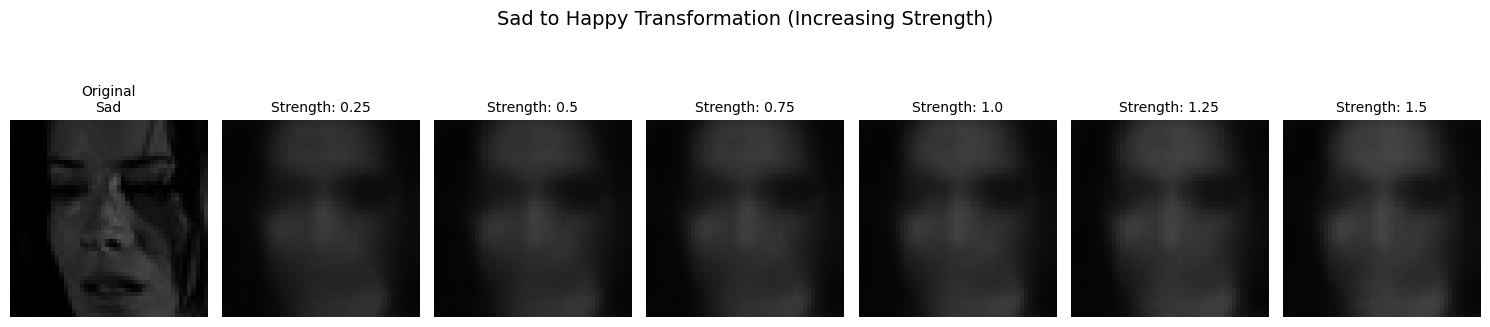


Happy to Sad Transformation


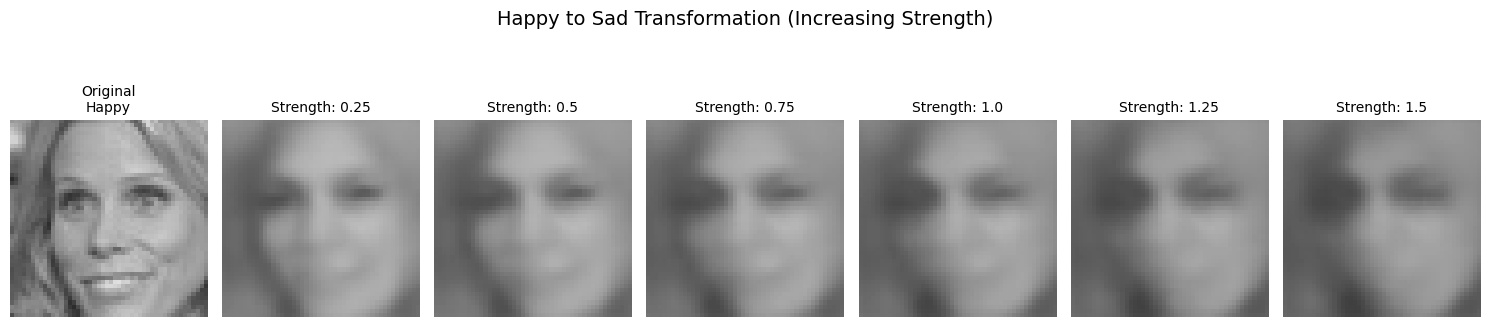

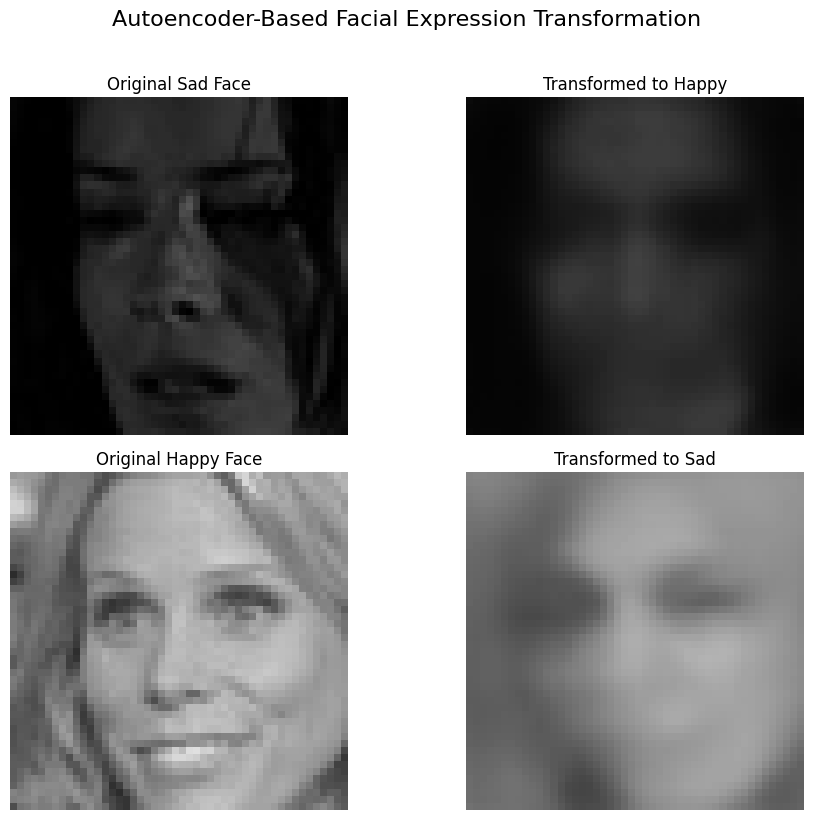

In [80]:
latent_codes = encoder.predict(X_normalized, batch_size=32, verbose=1)
sad_latent = latent_codes[y_filtered_labels == sad_label]
happy_latent = latent_codes[y_filtered_labels == happy_label]
mean_sad_latent = np.mean(sad_latent, axis=0)
mean_happy_latent = np.mean(happy_latent, axis=0)
smile_vector_latent = mean_happy_latent - mean_sad_latent


sad_example_idx = np.random.choice(np.where(y_filtered_labels == sad_label)[0])
happy_example_idx = np.random.choice(np.where(y_filtered_labels == happy_label)[0])
sad_example = X_normalized[sad_example_idx]
happy_example = X_normalized[happy_example_idx]

print(f"\nSelected sad face index: {sad_example_idx} (label: {y_filtered_labels[sad_example_idx]})")
print(f"Selected happy face index: {happy_example_idx} (label: {y_filtered_labels[happy_example_idx]})")


transformation_strengths = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]


print("\nSad to Happy Transformation")
fig, axes = plt.subplots(1, len(transformation_strengths), figsize=(15, 4))

for i, strength in enumerate(transformation_strengths):
    if strength == 0.0:
        transformed_img = sad_example
        title = f'Original\nSad'
    else:
        transformed_img, _, _ = transform_expression(
            sad_example, smile_vector_latent, strength=strength
        )
        title = f'Strength: {strength}'

    axes[i].imshow(transformed_img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sad to Happy Transformation (Increasing Strength)', fontsize=14)
plt.tight_layout()
plt.show()

# happy to sad
print("\nHappy to Sad Transformation")
fig, axes = plt.subplots(1, len(transformation_strengths), figsize=(15, 4))

for i, strength in enumerate(transformation_strengths):
    if strength == 0.0:
        transformed_img = happy_example
        title = f'Original\nHappy'
    else:
        transformed_img, _, _ = transform_expression(
            happy_example, -smile_vector_latent, strength=strength
        )
        title = f'Strength: {strength}'

    axes[i].imshow(transformed_img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Happy to Sad Transformation (Increasing Strength)', fontsize=14)
plt.tight_layout()
plt.show()


sad_to_happy, _, _ = transform_expression(sad_example, smile_vector_latent, strength=1.0)
happy_to_sad, _, _ = transform_expression(happy_example, -smile_vector_latent, strength=1.0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))


axes[0, 0].imshow(sad_example.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original Sad Face', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(sad_to_happy.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Transformed to Happy', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(happy_example.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Original Happy Face', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(happy_to_sad.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title('Transformed to Sad', fontsize=12)
axes[1, 1].axis('off')

fig.suptitle('Autoencoder-Based Facial Expression Transformation', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- качество исходных картинок оставляет желать лучшего, но какие-то намеки на трансформацию выражены сильнее, чем в случае с PCA.